In [3]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 1: 환경 + 팩터 레지스트리 + 레짐별 매핑
# =============================================================================
#
# [목적]
# 멀티팩터 조합 모델 구축
# 05_Factor v4 재검증 결과를 기반으로 레짐별 팩터 조합 설계
#
# [구조]
# Cell 1: 환경 + 팩터 레지스트리 + 레짐 매핑 (← 여기)
# Cell 2: 전 팩터 시그널 로드 + 통합 패널
# Cell 3: 팩터 간 상관 매트릭스 (미확인 쌍 포함)
# Cell 4: Phase 2 — 레짐별 동일가중 조합 백테스트 (베이스라인)
# Cell 5: Phase 3 — Bear 자산배분 레이어 (현금/채권 비중)
# Cell 6: Phase 4 — 이벤트 트리거 (G-1, T-1) 오버레이
# Cell 7: Phase 5 — 거래비용 민감도 + Walk-Forward
# Cell 8: 최종 결론 주석
#
# [핵심 설계 원칙]
# 1. H는 always-on 베이스 팩터 (전 레짐 WIN, t=12.3/7.7)
# 2. 레짐 스위치에 따라 보조 팩터 on/off
# 3. Bear 구간: 팩터 틸트(종목선정) + 자산배분(현금/채권) 분리
# 4. 이벤트 트리거(G-1, T-1)는 Core 스코어 가감 방식
# 5. 처음은 동일가중 → 과최적화 금지
#
# [레짐 체계]
# regime_v4 (3레짐 + bear_phase 보조):
#   Bull:    S&P500 > 10M SMA (상승장)
#   Bear:    S&P500 < 10M SMA (하락장)
#   Neutral: Bear→Bull 전환 후 3개월 이내
#   bear_phase: declining(MA 하향) / recovering(MA 상향)
#
# [v2→v4 레짐 매핑 참고]
#   v2 Expansion, Peak, Recovery_Late → v4 Bull
#   v2 Contraction, Crash             → v4 Bear
#   v2 Neutral, Recovery_Early        → v4 Neutral (정확히 1:1은 아님, 주의)
#   ⚠ v4에서는 v2의 세분화를 포기하고 단순화한 대신
#      bear_phase로 Bear 내부를 구분
#
# [백테스트 기간]
# 2013-06 ~ 2026-02 (약 151개월)
# 유니버스: 503 tickers (S&P500 + 과거 구성종목)
# 벤치마크: EW (동일가중)
# 거래비용: 20bp 편도 기준
# 리밸런싱: 월말 (이벤트 트리거 제외)
# Top N: 30 (기본)
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ─── 경로 (SSOT) ─────────────────────────────────────────────────────────────
QP2_ROOT = Path(r"C:\QP2")
DATA_DIR = QP2_ROOT / "data"
RAW_DIR  = DATA_DIR / "raw"
INTERIM  = DATA_DIR / "interim"
META_DIR = DATA_DIR / "meta"

PATHS = dict(
    px_wide     = INTERIM / "yahoo_adjclose_wide.parquet",
    ret_1m      = INTERIM / "ret_1m_wide.parquet",       # 월간 수익률 wide
    fund_q      = INTERIM / "fundamentals_quarterly.parquet",
    mktcap_m    = INTERIM / "mktcap_monthly.parquet",
    regime_v4   = INTERIM / "regime_v4.parquet",          # ★ v4 레짐
    regime_v2   = INTERIM / "regime_indicators_combined.parquet",  # 참고용
    universe    = META_DIR / "sp500_universe.parquet",
    fscore      = INTERIM / "fscore_signal.parquet",
    nsi         = INTERIM / "nsi_annual.parquet",
    insider     = INTERIM / "insider_mspr.parquet",
    p7_panel    = INTERIM / "p7_signal_panel.parquet",
)

# ─── 글로벌 파라미터 ──────────────────────────────────────────────────────────
TOP_N       = 30        # 포트폴리오 종목 수
COST_BP     = 20        # 편도 거래비용 (bp)
REBAL_FREQ  = "ME"      # 월말 리밸런싱
BT_START    = "2013-06"
BT_END      = "2026-02"

# ─── 유틸리티 함수 ────────────────────────────────────────────────────────────
def winsorize(s, lower=0.01, upper=0.99):
    """시리즈 윈저라이즈 (cross-sectional에서 날짜별로 사용)"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col, group_col="date"):
    """날짜별 횡단면 z-score"""
    return df.groupby(group_col)[col].transform(
        lambda x: (x - x.mean()) / x.std()
    )

def calc_perf(cum_ret):
    """누적수익률 시리즈 → CAGR, Sharpe, MaxDD"""
    total = cum_ret.iloc[-1] / cum_ret.iloc[0]
    years = len(cum_ret) / 12
    cagr  = total ** (1/years) - 1
    monthly_ret = cum_ret.pct_change().dropna()
    sharpe = monthly_ret.mean() / monthly_ret.std() * np.sqrt(12) if monthly_ret.std() > 0 else 0
    dd = cum_ret / cum_ret.cummax() - 1
    maxdd = dd.min()
    return {"CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd}

def calc_tstat(excess_monthly):
    """월간 초과수익률 → t-stat"""
    n = len(excess_monthly)
    if n < 3:
        return 0.0
    return excess_monthly.mean() / (excess_monthly.std() / np.sqrt(n))

def backtest_topn(signal_wide, ret_wide, n=TOP_N, cost_bp=COST_BP):
    """
    Top-N EW 포트폴리오 백테스트
    signal_wide: date × ticker (z-score, 높을수록 좋음)
    ret_wide:    date × ticker (월간 수익률)
    Returns: DataFrame with port_ret, bm_ret, excess, cum_port, cum_bm
    """
    common_dates = signal_wide.index.intersection(ret_wide.index)
    common_dates = sorted(common_dates)
    
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(common_dates[:-1]):
        next_dt = common_dates[i + 1]
        
        # 시그널 기준 Top N 선정
        scores = signal_wide.loc[dt].dropna()
        if len(scores) < n:
            continue
        top_n = scores.nlargest(n).index.tolist()
        
        # 수익률
        rets = ret_wide.loc[next_dt, top_n].dropna()
        if len(rets) == 0:
            continue
        port_ret = rets.mean()
        bm_ret   = ret_wide.loc[next_dt].dropna().mean()
        
        # 거래비용 (턴오버 기반)
        curr_set = set(top_n)
        if prev_holdings:
            turnover = len(curr_set - prev_holdings) / n
        else:
            turnover = 1.0
        cost = turnover * cost_bp * 2 / 10000  # 편도 × 2 (매수+매도)
        
        results.append({
            "date": next_dt,
            "port_ret_gross": port_ret,
            "port_ret_net": port_ret - cost,
            "bm_ret": bm_ret,
            "turnover": turnover,
            "n_stocks": len(rets),
        })
        prev_holdings = curr_set
    
    df = pd.DataFrame(results).set_index("date")
    df["excess_gross"] = df["port_ret_gross"] - df["bm_ret"]
    df["excess_net"]   = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"]     = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"]       = (1 + df["bm_ret"]).cumprod()
    return df


# =============================================================================
# ★ 팩터 레지스트리 — v4 재검증 최종 결과 기반
# =============================================================================
#
# 각 팩터의 메타데이터를 딕셔너리로 정의.
# 멀티팩터 조합 시 이 레지스트리를 참조하여 on/off, 가중치 등을 결정.
#
# 필드 설명:
#   name:        팩터 ID
#   desc:        한줄 설명
#   type:        "score" (z-score 기반, 합산 가능) / "filter" (이진, 종목 제외용)
#                / "event" (이벤트 트리거, 비정기)
#   direction:   "long" (높을수록 좋음) / "short" (낮을수록 좋음)
#   regimes:     유효 레짐 리스트 ["Bull", "Bear", "Neutral"]
#   role:        "main" / "aux" / "filter" / "avoid"
#   rebal:       "monthly" / "event"
#   tstat:       v4 재검증 대표 t-stat (레짐별 최고값)
#   params:      주요 파라미터
#   signal_src:  시그널 생성 소스 (어디서 로드/계산하는지)
#   note:        특이사항
#
# ⚠ 이 레지스트리는 "설계 사양서"이지 코드가 아님.
#    Cell 2에서 실제 시그널을 로드하고,
#    Cell 4에서 이 매핑대로 조합한다.
# =============================================================================

FACTOR_REGISTRY = {
    # ── always-on ──────────────────────────────────────────────────────────
    "H": {
        "desc":      "섹터 모멘텀 (3M lookback)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bull", "Bear", "Neutral"],   # 전 레짐 WIN
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Bull": 12.3, "Bear": 7.7, "Neutral": 2.16},
        "params":    {"lookback_m": 3},
        "signal_src": "02_H.ipynb → h_z_wide (date×ticker z-score)",
        "note":      "MVP. IT 편향 주의. 전 레짐 베이스로 항상 ON.",
    },
    
    # ── Bull 팩터 ──────────────────────────────────────────────────────────
    "T-1": {
        "desc":      "리더 급등 spillover (Bull 전용 가산)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "event",   # hold=7d, 비정기
        "tstat":     {"Bull": 3.21},
        "params":    {"surge_sigma": 2.5, "hold_d": 7, "tier": "Top_Q4"},
        "signal_src": "02_T-1.ipynb → 인라인 계산 (일간 이벤트)",
        "note":      "Core 스코어에 z-score 가산. 리밸런싱 시 직전 7일 이벤트 체크.",
    },
    "P-7": {
        "desc":      "Net Stock Issuance (자사주 매입 = 높은 점수)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bull": 2.43},
        "params":    {"n_top": 50},   # N=50에서 t=2.20
        "signal_src": "02_P-7.ipynb → nsi_score (nsi_annual.parquet)",
        "note":      "회전율 7.4%로 공짜에 가까움. Crash에서 역작동 주의.",
    },
    "G-1_bull": {
        "desc":      "급락 반전 매수 (Bull, lookback=3M)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bull"],
        "role":      "aux",
        "rebal":     "monthly",   # hold=20 → 사실상 월간
        "tstat":     {"Bull": 2.55},
        "params":    {"lookback_m": 3, "hold_d": 20},
        "signal_src": "05_G-1.ipynb → 인라인 계산",
        "note":      "hold=20이라 월간 리밸런싱에 편입 가능.",
    },
    
    # ── Bear 팩터 ──────────────────────────────────────────────────────────
    "A-3": {
        "desc":      "Value × Catalyst (저평가+개선 기업)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Bear": 2.21},
        "params":    {"lag_days": 45, "value_filter_pct": 0.5},
        "signal_src": "02_A.ipynb → signal_df (value_filter + catalyst_z)",
        "note":      "큰 알파(+72.6%) but 큰 변동. Bear 메인이지만 현금/채권이 우월함을 잊지 말 것.",
    },
    "G-1_bear": {
        "desc":      "급락 반전 매수 (Bear, lookback=5M)",
        "type":      "event",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bear": 7.78},
        "params":    {"lookback_m": 5, "hold_d": 20},
        "signal_src": "05_G-1.ipynb → 인라인 계산",
        "note":      "v4 재검증 최고 t-stat. Bear 급락 반전 시 강력.",
    },
    "P-5": {
        "desc":      "저베타 (Betting Against Beta)",
        "type":      "score",
        "direction": "long",   # 저베타 = 높은 BAB score
        "regimes":   ["Bear"],
        "role":      "stability",
        "rebal":     "monthly",
        "tstat":     {"Bear": 4.25},
        "params":    {"window_m": 12},
        "signal_src": "05_E_P5.ipynb → beta_long → -beta z-score",
        "note":      "v4 부활. Bear CAGR=-18.21%로 '덜 잃기'. 회전율 10.8%.",
    },
    "E-5": {
        "desc":      "저변동 (Low Idiosyncratic Vol)",
        "type":      "score",
        "direction": "long",   # 저변동 = 높은 점수
        "regimes":   ["Bear"],
        "role":      "stability",
        "rebal":     "monthly",
        "tstat":     {"Bear": 4.70},
        "params":    {"window_m": 6},
        "signal_src": "05_E_P5.ipynb → ivol → -ivol z-score",
        "note":      "v4 부활. P-5와 상관 -0.37 (반대 방향 → 분산 효과).",
    },
    "D-1": {
        "desc":      "단순 모멘텀 12-1 (Bear 보조)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Bear"],
        "role":      "aux",
        "rebal":     "monthly",
        "tstat":     {"Bear": 0.18},
        "params":    {"lookback": "MOM_12_1"},
        "signal_src": "02_D.ipynb → mom_signals['MOM_12_1']",
        "note":      "방향 맞지만 불안정 (t=0.18). 보조로만.",
    },
    "G-1b": {
        "desc":      "급등 회피 시그널 (Bear/Neutral)",
        "type":      "filter",
        "direction": "short",  # 급등 종목 회피 → 낮을수록 좋음(=감점)
        "regimes":   ["Bear", "Neutral"],
        "role":      "avoid",
        "rebal":     "monthly",
        "tstat":     {"Bear": -2.05, "Neutral": -2.31},
        "params":    {},
        "signal_src": "05_G-1.ipynb → 급등 종목 플래그",
        "note":      "Bear에서 급등=함정. 합산 스코어에서 감점 처리.",
    },
    
    # ── Neutral 팩터 ───────────────────────────────────────────────────────
    "D-3": {
        "desc":      "변동성 조정 모멘텀 (MOM_3_1 / VOL)",
        "type":      "score",
        "direction": "long",
        "regimes":   ["Neutral"],
        "role":      "main",
        "rebal":     "monthly",
        "tstat":     {"Neutral": 2.52},   # Sharpe 기준
        "params":    {"lookback": "MOM_3_1", "vol_window": "6M"},
        "signal_src": "02_D.ipynb → mom_vol_adj (MOM_3_1/VOL)",
        "note":      "v4에서 MOM_3_1/VOL로 재정의. Neutral 메인.",
    },
    
    # ── 리스크 필터 (단독 팩터 아님) ──────────────────────────────────────
    "F-1": {
        "desc":      "Piotroski F-score (리스크 필터)",
        "type":      "filter",
        "direction": "long",  # 높은 F-score = 건전
        "regimes":   ["Bear"],
        "role":      "filter",
        "rebal":     "monthly",
        "tstat":     {"Bear": 0.09},   # v4에서 대폭 약화
        "params":    {"version": "C", "lag_days": 0},
        "signal_src": "02_F.ipynb → fscore_signal.parquet",
        "note":      "v2 +11%p → v4 +0.4%. A-3 필터(저품질 제거)로 전환 고려.",
    },
}


# =============================================================================
# ★ 레짐별 팩터 매핑 — 06_Multi 설계 핵심
# =============================================================================
#
# 각 레짐에서 어떤 팩터를 어떤 역할로 사용할지 정의.
# Phase 2에서는 동일가중으로 시작 (weight는 나중에 최적화).
#
# 구조: {레짐: [팩터ID 리스트]}
# "score" 타입만 z-score 합산 대상.
# "filter" 타입은 합산 후 하위 종목 제외.
# "event" 타입은 합산 후 가산/감점.
# =============================================================================

REGIME_FACTOR_MAP = {
    "Bull": {
        "scores":  ["H", "G-1_bull", "P-7"],    # z-score 합산 (동일가중)
        "events":  ["T-1"],                       # 이벤트 시 가산
        "filters": [],                            # Bull에서는 필터 없음
        "avoids":  [],                            # Bull에서 급등 = 모멘텀 (회피 안 함)
    },
    "Bear": {
        "scores":  ["H", "A-3", "P-5", "E-5", "D-1"],  # z-score 합산
        "events":  ["G-1_bear"],                         # 급락 반전 시 가산
        "filters": ["F-1"],                              # 저품질 제거
        "avoids":  ["G-1b"],                             # 급등 종목 감점
    },
    "Neutral": {
        "scores":  ["H", "D-3"],                 # z-score 합산
        "events":  [],                            # Neutral은 이벤트 팩터 없음
        "filters": [],
        "avoids":  ["G-1b"],                      # 급등 종목 감점
    },
}

# =============================================================================
# ★ Bear 자산배분 파라미터 — Phase 3
# =============================================================================
#
# Bear에서 현금/채권 비중 조절 로직.
# 이진법(0/100)이 아니라 점진적 전환.
#
# Bear 진입:
#   1개월차 → cash_weight = 0.30
#   2개월차 → cash_weight = 0.50
#   3개월+ → cash_weight = 0.70 (최대)
#
# Bear 탈출 (bear_phase: declining → recovering):
#   recovering 1개월차 → cash_weight 한 단계 축소
#   Bull 확정(S&P > 10M SMA) → 한 단계 더 축소
#   2~3개월에 걸쳐 완전 복귀
#
# ⚠ Bear 팩터의 진짜 역할: 덜 잃기. 현금/채권(0%)이 모든 주식 전략보다 우월.
#    팩터 틸트는 "레짐 전환 초기" + "자산배분 결정 전 버퍼" 용도.
# =============================================================================

BEAR_ALLOC = {
    "bear_month_1": 0.30,   # 주식 70%
    "bear_month_2": 0.50,   # 주식 50%
    "bear_month_3+": 0.70,  # 주식 30% (최대 현금)
    "recovering_step": -0.20,  # recovering 전환 시 현금 비중 20%p 감소
    "bull_confirmed_step": -0.20,  # Bull 확정 시 추가 20%p 감소
    "min_cash": 0.0,        # 최소 현금 (Bull 확정 후)
    "max_cash": 0.70,       # 최대 현금
}

# =============================================================================
# ★ 이벤트 트리거 파라미터 — Phase 4
# =============================================================================
#
# 정기 리밸런싱(월말): H, A-3, D-3, P-5, E-5, P-7, D-1
# 이벤트 트리거: G-1(급락), T-1(리더 급등)
#
# 설계:
#   Core 스코어 = Σ(레짐별 score 팩터 z-scores) (동일가중)
#   이벤트 발생 시 → Core 스코어에 가산/감점 → 다음 리밸런싱에 반영
#   (별도 satellite 버킷 없음)
#
# T-1: Bull에서 리더 2.5σ 급등 → 해당 섹터 Top Q4 z-score +1.0 가산
#      Neutral에서 리더 2.5σ 급등 → Lag Q1 z-score -1.0 감점
# G-1: 급락 감지 시 → 해당 종목 z-score +1.0 가산
#
# 월말 리밸런싱 시, 직전 hold_d 이내 이벤트를 체크하여 반영.
# =============================================================================

EVENT_PARAMS = {
    "T-1a": {
        "regime": "Bull",
        "surge_sigma": 2.5,
        "hold_d": 7,
        "bonus_z": 1.0,        # Top Q4에 가산
        "tier": "Top_Q4",
    },
    "T-1b": {
        "regime": "Neutral",
        "surge_sigma": 2.5,
        "hold_d": 5,
        "penalty_z": -1.0,     # Lag Q1에 감점
        "tier": "Lag_Q1",
    },
    "G-1": {
        "regimes": ["Bull", "Bear"],
        "hold_d": 20,
        "bonus_z": 1.0,        # 급락 종목에 가산
    },
}

# =============================================================================
# ★ 미확인 상관 쌍 체크리스트
# =============================================================================
#
# 확인 완료:
#   P-5 vs E-5:   신호 -0.005, 수익 -0.37 → 독립 ✅
#   P-5 vs D:     신호 -0.056 → 독립 ✅
#   H vs D-3:     신호 0.22, 수익 0.70, 겹침 10% → 독립 ✅
#   H vs D-1:     신호 0.12, 수익 0.66, 겹침 10% → 독립 ✅
#   T-1 vs H:     신호 -0.004, 겹침 98.5% → 완전독립 ✅
#
# ⚠ 미확인 (Cell 3에서 반드시 확인):
#   G-1 vs D-1    — 방향 반대(급락반전 vs 모멘텀)일 가능성 높지만 미확인
#   G-1 vs P-5    — 이벤트성 vs 구조적 특성, 시간축 다름
#   G-1 vs E-5    — 위와 동일 논리
#   A-3 vs P-5    — accrual vs beta, 논리적 독립이나 미확인
#   A-3 vs E-5    — accrual vs ivol, 논리적 독립이나 미확인
#
# → Cell 3에서 상관 매트릭스 찍고 여기에 결과 업데이트할 것.
# =============================================================================

UNCHECKED_PAIRS = [
    ("G-1", "D-1"),
    ("G-1", "P-5"),
    ("G-1", "E-5"),
    ("A-3", "P-5"),
    ("A-3", "E-5"),
]

# ─── 확인 ─────────────────────────────────────────────────────────────────────
print("="*60)
print("🔨 06_TheForge — Cell 1 로드 완료")
print("="*60)
print(f"  팩터 레지스트리: {len(FACTOR_REGISTRY)}개")
print(f"  레짐: {list(REGIME_FACTOR_MAP.keys())}")
print(f"  미확인 상관 쌍: {len(UNCHECKED_PAIRS)}개")
print(f"  백테스트: {BT_START} ~ {BT_END}")
print(f"  거래비용: {COST_BP}bp 편도")
print()
for regime, mapping in REGIME_FACTOR_MAP.items():
    scores = mapping["scores"]
    events = mapping.get("events", [])
    filters = mapping.get("filters", [])
    avoids = mapping.get("avoids", [])
    print(f"  [{regime}]")
    print(f"    scores:  {scores}")
    if events:  print(f"    events:  {events}")
    if filters: print(f"    filters: {filters}")
    if avoids:  print(f"    avoids:  {avoids}")
    print()
print("→ Cell 2에서 전 팩터 시그널 로드 시작")

🔨 06_TheForge — Cell 1 로드 완료
  팩터 레지스트리: 12개
  레짐: ['Bull', 'Bear', 'Neutral']
  미확인 상관 쌍: 5개
  백테스트: 2013-06 ~ 2026-02
  거래비용: 20bp 편도

  [Bull]
    scores:  ['H', 'G-1_bull', 'P-7']
    events:  ['T-1']

  [Bear]
    scores:  ['H', 'A-3', 'P-5', 'E-5', 'D-1']
    events:  ['G-1_bear']
    filters: ['F-1']
    avoids:  ['G-1b']

  [Neutral]
    scores:  ['H', 'D-3']
    avoids:  ['G-1b']

→ Cell 2에서 전 팩터 시그널 로드 시작


In [4]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 2: 팩터 시그널 로드 + 통합 패널 + 상관행렬
# =============================================================================
#
# [목적]
# 각 05_*.ipynb에서 저장한 parquet 시그널을 로드하고
# 하나의 통합 패널 (date × ticker × 팩터별 z-score)로 병합.
# 미확인 상관 쌍 체크까지 포함.
#
# [로드 파일]
#   h_signal.parquet       → h_z         (H: 섹터 모멘텀)
#   d_signal.parquet       → d1_z, d3_z  (D-1: 모멘텀, D-3: 변동성조정모멘텀)
#   a3_signal.parquet      → a3_z        (A-3: 가치×촉매)
#   p5_e5_signal.parquet   → p5_z, e5_z  (P-5: 저베타, E-5: 저변동)
#   g1_signal.parquet      → g1_bull_z, g1_bear_z, g1b_flag
#   t1_events.parquet      → 이벤트 테이블 (별도 보관)
#   fscore_signal.parquet  → fscore      (F-1: 리스크 필터)
#   p7_signal_panel.parquet→ nsi_score   (P-7: 자사주매입)
#   regime_v4.parquet      → regime, bear_phase
#   ret_1m_wide.parquet    → 월간 수익률 (백테스트용)
#
# [산출물]
#   panel: DataFrame (date, ticker, h_z, d1_z, d3_z, a3_z, p5_z, e5_z,
#                     g1_bull_z, g1_bear_z, g1b_flag, nsi_score, fscore,
#                     regime, bear_phase)
#   ret_1m: wide format 월간 수익률
#   t1_events: 이벤트 테이블
#   corr_matrix: 팩터 간 상관행렬
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 1. 팩터 시그널 로드 ──────────────────────────────────────────────────────

print("=" * 60)
print("📦 팩터 시그널 로드 시작")
print("=" * 60)

# H: 섹터 모멘텀
h_sig = pd.read_parquet(SAVE_DIR / "h_signal.parquet")
h_sig["date"] = pd.to_datetime(h_sig["date"])
print(f"  H:    {len(h_sig):>8,} rows, {h_sig['ticker'].nunique()} tickers")

# D: 모멘텀
d_sig = pd.read_parquet(SAVE_DIR / "d_signal.parquet")
d_sig["date"] = pd.to_datetime(d_sig["date"])
print(f"  D:    {len(d_sig):>8,} rows, {d_sig['ticker'].nunique()} tickers")

# A-3: 가치×촉매
a3_sig = pd.read_parquet(SAVE_DIR / "a3_signal.parquet")
a3_sig["date"] = pd.to_datetime(a3_sig["date"])
print(f"  A-3:  {len(a3_sig):>8,} rows, {a3_sig['ticker'].nunique()} tickers")

# P-5 + E-5: 저베타 + 저변동
p5e5_sig = pd.read_parquet(SAVE_DIR / "p5_e5_signal.parquet")
p5e5_sig["date"] = pd.to_datetime(p5e5_sig["date"])
print(f"  P5E5: {len(p5e5_sig):>8,} rows, {p5e5_sig['ticker'].nunique()} tickers")

# G-1: 급락반전 + 급등회피
g1_sig = pd.read_parquet(SAVE_DIR / "g1_signal.parquet")
g1_sig["date"] = pd.to_datetime(g1_sig["date"])
print(f"  G-1:  {len(g1_sig):>8,} rows, {g1_sig['ticker'].nunique()} tickers")

# T-1: 이벤트 테이블 (별도 보관, panel에 안 넣음)
t1_events = pd.read_parquet(SAVE_DIR / "t1_events.parquet")
if len(t1_events) > 0:
    t1_events["date"] = pd.to_datetime(t1_events["date"])
print(f"  T-1:  {len(t1_events):>8,} events")

# F-1: Piotroski F-score
f_sig = pd.read_parquet(SAVE_DIR / "fscore_signal.parquet")
f_sig["date"] = pd.to_datetime(f_sig["date"])
# fscore_signal에서 필요한 컬럼만 추출
f_cols = ["date", "ticker", "fscore"] if "ticker" in f_sig.columns else ["date", "ticker_yahoo", "fscore"]
f_sig = f_sig[f_cols].copy()
if "ticker_yahoo" in f_sig.columns:
    f_sig = f_sig.rename(columns={"ticker_yahoo": "ticker"})
print(f"  F-1:  {len(f_sig):>8,} rows, {f_sig['ticker'].nunique()} tickers")

# P-7: NSI (자사주매입)
p7_sig = pd.read_parquet(SAVE_DIR / "p7_signal_panel.parquet")
p7_sig["date"] = pd.to_datetime(p7_sig["date"])
# nsi_score 컬럼 추출 (= -nsi_z, 자사주매입=높은 점수)
p7_cols = [c for c in ["date", "ticker", "nsi_score"] if c in p7_sig.columns]
if "nsi_score" not in p7_sig.columns:
    # nsi_z가 있으면 부호 반전
    if "nsi_z" in p7_sig.columns:
        p7_sig["nsi_score"] = -p7_sig["nsi_z"]
        p7_cols = ["date", "ticker", "nsi_score"]
p7_sig = p7_sig[p7_cols].copy()
print(f"  P-7:  {len(p7_sig):>8,} rows, {p7_sig['ticker'].nunique()} tickers")

# ─── 2. 레짐 로드 ────────────────────────────────────────────────────────────

regime_v4 = pd.read_parquet(SAVE_DIR / "regime_v4.parquet")
regime_v4.index = pd.to_datetime(regime_v4.index)
regime_v4 = regime_v4.reset_index()
regime_v4 = regime_v4.rename(columns={"index": "date"})
regime_v4["date"] = pd.to_datetime(regime_v4["date"]) + pd.offsets.MonthEnd(0)
regime_map = regime_v4.set_index("date")[["regime", "bear_phase"]].to_dict("index")

print(f"\n  레짐: {regime_v4['regime'].value_counts().to_dict()}")
print(f"  Bear 내부: {regime_v4[regime_v4['regime']=='Bear']['bear_phase'].value_counts().to_dict()}")

# ─── 3. 월간 수익률 로드 ──────────────────────────────────────────────────────

ret_1m = pd.read_parquet(SAVE_DIR / "ret_1m_wide.parquet")
if "date" in ret_1m.columns:
    ret_1m = ret_1m.set_index("date")
ret_1m.index = pd.to_datetime(ret_1m.index)
print(f"\n  ret_1m: {ret_1m.shape[0]} months × {ret_1m.shape[1]} tickers")

# ─── 4. 통합 패널 병합 ───────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("🔗 통합 패널 병합")
print("=" * 60)

# 기준: H 시그널 (전 레짐 항상 ON, 가장 넓은 커버리지)
panel = h_sig[["date", "ticker", "h_z"]].copy()

# D 병합
panel = panel.merge(d_sig[["date", "ticker", "d1_z", "d3_z"]], 
                    on=["date", "ticker"], how="left")

# A-3 병합 (is_cheap 필터 이미 적용됨 → non-cheap은 NaN)
a3_merge = a3_sig[["date", "ticker", "a3_z"]].copy()
panel = panel.merge(a3_merge, on=["date", "ticker"], how="left")

# P-5 + E-5 병합
panel = panel.merge(p5e5_sig[["date", "ticker", "p5_z", "e5_z"]], 
                    on=["date", "ticker"], how="left")

# G-1 병합
panel = panel.merge(g1_sig[["date", "ticker", "g1_bull_z", "g1_bear_z", "g1b_flag"]], 
                    on=["date", "ticker"], how="left")

# P-7 병합
panel = panel.merge(p7_sig, on=["date", "ticker"], how="left")

# F-1 병합
panel = panel.merge(f_sig, on=["date", "ticker"], how="left")

# 레짐 병합
regime_slim = regime_v4[["date", "regime", "bear_phase"]].copy()
panel = panel.merge(regime_slim, on="date", how="left")

# 분석 기간 필터
panel = panel[(panel["date"] >= BT_START) & (panel["date"] <= BT_END)]

print(f"  패널 shape: {panel.shape}")
print(f"  기간: {panel['date'].min()} ~ {panel['date'].max()}")
print(f"  고유 날짜: {panel['date'].nunique()}")
print(f"  고유 종목: {panel['ticker'].nunique()}")

# 팩터별 커버리지
print(f"\n  팩터별 non-null 비율:")
factor_cols = ["h_z", "d1_z", "d3_z", "a3_z", "p5_z", "e5_z", 
               "g1_bull_z", "g1_bear_z", "g1b_flag", "nsi_score", "fscore"]
for col in factor_cols:
    if col in panel.columns:
        pct = panel[col].notna().mean() * 100
        print(f"    {col:14s}: {pct:5.1f}%")

# ─── 5. 상관 매트릭스 (미확인 쌍 포함) ───────────────────────────────────────

print("\n" + "=" * 60)
print("📊 팩터 간 상관행렬 (횡단면 평균)")
print("=" * 60)

# 각 날짜별 횡단면 상관 → 평균
score_cols = ["h_z", "d1_z", "d3_z", "a3_z", "p5_z", "e5_z", 
              "g1_bull_z", "g1_bear_z", "nsi_score"]

corr_by_date = []
for dt, grp in panel.groupby("date"):
    sub = grp[score_cols].dropna(how="all")
    if len(sub) > 30:  # 최소 30종목
        corr_by_date.append(sub.corr())

if corr_by_date:
    corr_matrix = pd.concat(corr_by_date).groupby(level=0).mean()
    
    # 소수점 3자리로 표시
    print(corr_matrix.round(3).to_string())
    
    # 미확인 쌍 집중 확인
    print("\n" + "-" * 50)
    print("미확인 쌍 상관계수:")
    print("-" * 50)
    check_pairs = [
        ("g1_bull_z", "d1_z",    "G-1 vs D-1"),
        ("g1_bear_z", "d1_z",    "G-1(Bear) vs D-1"),
        ("g1_bull_z", "p5_z",    "G-1 vs P-5"),
        ("g1_bear_z", "e5_z",    "G-1(Bear) vs E-5"),
        ("a3_z",      "p5_z",    "A-3 vs P-5"),
        ("a3_z",      "e5_z",    "A-3 vs E-5"),
        ("p5_z",      "e5_z",    "P-5 vs E-5 (확인용)"),
        ("h_z",       "d3_z",    "H vs D-3 (확인용)"),
    ]
    for c1, c2, label in check_pairs:
        if c1 in corr_matrix.columns and c2 in corr_matrix.index:
            val = corr_matrix.loc[c1, c2]
            flag = "⚠" if abs(val) > 0.5 else "✅"
            print(f"  {flag} {label:25s}: {val:+.3f}")
        else:
            print(f"  ❓ {label:25s}: 데이터 없음")
else:
    print("  ⚠ 상관행렬 계산 불가 (데이터 부족)")
    corr_matrix = pd.DataFrame()

# ─── 6. 레짐별 팩터 분포 요약 ─────────────────────────────────────────────────

print("\n" + "=" * 60)
print("📈 레짐별 데이터 분포")
print("=" * 60)

for regime in ["Bull", "Bear", "Neutral"]:
    sub = panel[panel["regime"] == regime]
    n_months = sub["date"].nunique()
    n_rows = len(sub)
    print(f"\n  [{regime}] {n_months} months, {n_rows:,} rows")
    
    # 해당 레짐에서 사용할 팩터 커버리지
    regime_factors = REGIME_FACTOR_MAP[regime]["scores"]
    for factor_name in regime_factors:
        # 팩터명 → 컬럼명 매핑
        col_map = {
            "H": "h_z", "D-3": "d3_z", "D-1": "d1_z", "A-3": "a3_z",
            "P-5": "p5_z", "E-5": "e5_z", "G-1_bull": "g1_bull_z",
            "G-1_bear": "g1_bear_z", "P-7": "nsi_score",
        }
        col = col_map.get(factor_name, "")
        if col and col in sub.columns:
            pct = sub[col].notna().mean() * 100
            print(f"    {factor_name:10s} ({col:12s}): {pct:5.1f}% non-null")

print("\n" + "=" * 60)
print("✅ Cell 2 완료: 통합 패널 + 상관행렬")
print(f"   panel: {panel.shape}")
print(f"   t1_events: {len(t1_events)} events")
print(f"   ret_1m: {ret_1m.shape}")
print("→ Cell 3에서 레짐별 동일가중 백테스트 시작")
print("=" * 60)

📦 팩터 시그널 로드 시작
  H:     205,224 rows, 503 tickers
  D:      69,834 rows, 467 tickers
  A-3:    97,908 rows, 492 tickers
  P5E5:  206,504 rows, 503 tickers
  G-1:    72,374 rows, 503 tickers
  T-1:     1,533 events
  F-1:    88,324 rows, 503 tickers
  P-7:   387,310 rows, 503 tickers

  레짐: {'Bull': 551, 'Bear': 170, 'Neutral': 44}
  Bear 내부: {'declining': 151, 'recovering': 19}

  ret_1m: 770 months × 277 tickers

🔗 통합 패널 병합
  패널 shape: (76456, 15)
  기간: 2013-06-30 00:00:00 ~ 2026-01-31 00:00:00
  고유 날짜: 152
  고유 종목: 503

  팩터별 non-null 비율:
    h_z           : 100.0%
    d1_z          :  85.2%
    d3_z          :  90.7%
    a3_z          :  34.9%
    p5_z          :  95.3%
    e5_z          :  95.8%
    g1_bull_z     :  94.0%
    g1_bear_z     :  92.7%
    g1b_flag      :  94.0%
    nsi_score     :  84.1%
    fscore        :  93.5%

📊 팩터 간 상관행렬 (횡단면 평균)
             h_z   d1_z   d3_z   a3_z   p5_z   e5_z  g1_bull_z  g1_bear_z  nsi_score
a3_z      -0.013  0.078  0.022  1.000 -0.006 -0.0

🔨 Phase 2: 레짐별 동일가중 조합 백테스트

  백테스트 기간: 2013-07-31 00:00:00 ~ 2026-01-31 00:00:00
  총 151 months

전체 기간 성과 요약
                          Portfolio EW Benchmark
  CAGR                       11.7%       14.4%
  Sharpe                       0.79         0.99
  MaxDD                     -16.2%      -24.1%
  Excess (ann.)              -2.4%
  t-stat                      -0.93
  Avg Turnover               77.0%

레짐별 성과 분해
  Regime       Months     CAGR  BM_CAGR   Excess  t-stat  Sharpe  BM_Shp  Turnover
  --------------------------------------------------------------------------------
  Bull            115    9.6%   12.3%   -2.2%   -0.77    0.70    1.08    77.5%  LOSE
  Bear             23   20.8%   20.5%   +0.1%    0.01    1.09    0.87    67.8%  WIN
  Neutral          13   16.3%   24.9%   -9.4%   -0.98    1.14    1.62    89.2%  LOSE

  Bear 내부:
    declining   : n=22  CAGR=+22.8%  BM=+23.5%  Excess=-0.8%  t=-0.08
    recovering: 데이터 부족 (n=1)


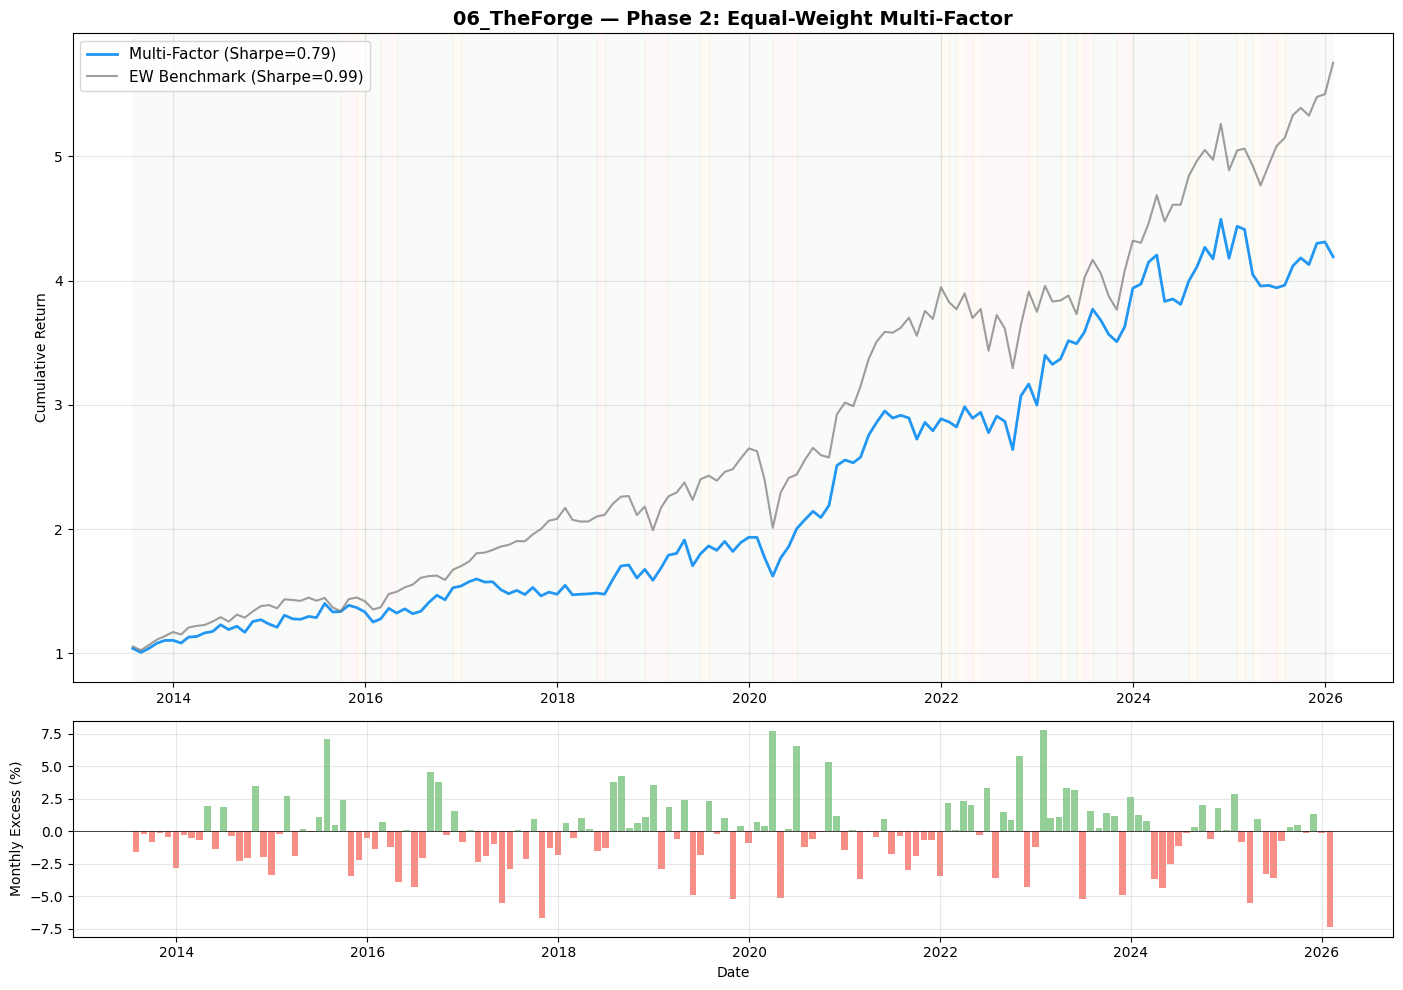


Phase 2 결론
  레짐별 승률: 1/3
  전체 t-stat: -0.93 (미달)
  전체 Sharpe: 0.79 (BM: 0.99)
  평균 턴오버: 77.0%

  → BM 대비 Sharpe 열위. 팩터 조합 재검토 필요.

→ Cell 4에서 Phase 3 (Bear 자산배분 레이어) 진행


In [6]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 3: Phase 2 — 레짐별 동일가중 조합 백테스트
# =============================================================================
#
# [목적]
# Cell 1의 REGIME_FACTOR_MAP에 따라, 레짐별로 다른 팩터 조합을 적용.
# 동일가중(equal-weight) z-score 합산 → Top N 선정 → 백테스트.
# Phase 2 = 베이스라인. 여기서 성과 확인 후 가중치/자산배분 추가.
#
# [로직]
# 매월 말:
#   1) 해당 월의 regime 확인 (Bull/Bear/Neutral)
#   2) REGIME_FACTOR_MAP[regime]["scores"]에 해당하는 팩터 z-score 합산
#   3) "avoids" 팩터 감점 (g1b_flag=1이면 합산 스코어에서 -2.0)
#   4) "filters" 적용 (F-1: Bear에서 fscore 하위 20% 제외)
#   5) T-1 이벤트 가산 (직전 hold_d 이내 이벤트 있으면 해당 섹터 +1.0)
#   6) Top N 선정 → t+1월 수익률로 성과 측정
#
# [레짐 래그]
# t월 말 regime 판정 → t+1월 초 리밸런싱 → t+1월 수익률 반영
# → look-ahead bias 없음 ✅ (Cell 2에서 확인 완료)
#
# [산출물]
# bt_multi: 월별 성과 DataFrame (date, port_ret, bm_ret, excess, regime, ...)
# 레짐별 + 전체 성과 요약
# =============================================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ─── 팩터명 → 컬럼명 매핑 ────────────────────────────────────────────────────
FACTOR_COL_MAP = {
    "H":        "h_z",
    "D-3":      "d3_z",
    "D-1":      "d1_z",
    "A-3":      "a3_z",
    "P-5":      "p5_z",
    "E-5":      "e5_z",
    "G-1_bull": "g1_bull_z",
    "G-1_bear": "g1_bear_z",
    "P-7":      "nsi_score",
}

# ─── 섹터 매핑 (T-1 이벤트용) ─────────────────────────────────────────────────
universe = pd.read_parquet(Path(r"C:\QP2\data\meta") / "sp500_universe.parquet")
ticker_to_sector = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()

# ─── 백테스트 파라미터 ────────────────────────────────────────────────────────
AVOID_PENALTY  = -2.0    # g1b_flag=1 종목에 대한 감점
T1_BONUS       = 1.0     # T-1 이벤트 가산
T1_LOOKBACK_D  = 7       # T-1 이벤트 체크 기간 (Bull)
F1_CUTOFF_PCT  = 0.20    # F-1 필터: 하위 20% 제거 (Bear)

# ─── 메인 백테스트 ────────────────────────────────────────────────────────────

print("=" * 70)
print("🔨 Phase 2: 레짐별 동일가중 조합 백테스트")
print("=" * 70)

# 월말 날짜 정렬
all_dates = sorted(panel["date"].unique())
# BT_START ~ BT_END 필터
all_dates = [d for d in all_dates if BT_START <= str(d)[:7] <= BT_END]

results = []
prev_holdings = set()

for i, dt in enumerate(all_dates[:-1]):
    next_dt = all_dates[i + 1]
    
    # ── 1) 레짐 판정 ──
    regime_info = regime_map.get(dt, None)
    if regime_info is None:
        # 월말 날짜 매칭 시도
        dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
        regime_info = regime_map.get(dt_me, None)
    if regime_info is None:
        continue
    
    regime = regime_info["regime"]
    bear_phase = regime_info.get("bear_phase", "")
    
    # ── 2) 해당 월 종목 데이터 ──
    month_data = panel[panel["date"] == dt].copy()
    if len(month_data) < TOP_N:
        continue
    
    # ── 3) 레짐별 팩터 조합 ──
    factor_map = REGIME_FACTOR_MAP[regime]
    score_factors = factor_map["scores"]
    
    # 동일가중 z-score 합산
    score_cols = [FACTOR_COL_MAP[f] for f in score_factors if f in FACTOR_COL_MAP]
    
    # 각 팩터가 NaN인 경우 해당 팩터만 제외하고 나머지로 평균
    month_data["composite_z"] = month_data[score_cols].mean(axis=1)
    
    # ── 4) Avoids 감점 ──
    if "G-1b" in factor_map.get("avoids", []):
        mask_avoid = month_data["g1b_flag"] == 1
        month_data.loc[mask_avoid, "composite_z"] += AVOID_PENALTY
    
    # ── 5) F-1 필터 (Bear만) ──
    if "F-1" in factor_map.get("filters", []):
        fscore_valid = month_data["fscore"].dropna()
        if len(fscore_valid) > 0:
            cutoff = fscore_valid.quantile(F1_CUTOFF_PCT)
            # 하위 20% 제거 (composite_z를 NaN으로)
            mask_low_f = month_data["fscore"] < cutoff
            month_data.loc[mask_low_f, "composite_z"] = np.nan
    
    # ── 6) T-1 이벤트 가산 (Bull만) ──
    if "T-1" in factor_map.get("events", []) and len(t1_events) > 0:
        # 직전 T1_LOOKBACK_D 이내 이벤트
        dt_ts = pd.Timestamp(dt)
        recent_events = t1_events[
            (t1_events["date"] >= dt_ts - pd.Timedelta(days=T1_LOOKBACK_D)) &
            (t1_events["date"] <= dt_ts)
        ]
        if len(recent_events) > 0:
            event_sectors = set(recent_events["sector"].unique())
            for idx, row in month_data.iterrows():
                tk = row["ticker"]
                sector = ticker_to_sector.get(tk, "")
                if sector in event_sectors:
                    month_data.loc[idx, "composite_z"] += T1_BONUS
    
    # ── 7) G-1 이벤트 가산 (Bull: g1_bull_z 이미 scores에 포함, 별도 처리 불필요) ──
    # G-1_bear 이벤트도 scores에 포함되어 있으므로 별도 처리 불필요
    
    # ── 8) Top N 선정 ──
    valid = month_data.dropna(subset=["composite_z"])
    if len(valid) < TOP_N:
        # 유효 종목 부족 시 가능한 만큼
        top_n_actual = max(10, len(valid))
    else:
        top_n_actual = TOP_N
    
    top = valid.nlargest(top_n_actual, "composite_z")
    selected_tickers = top["ticker"].tolist()
    
    # ── 9) 수익률 계산 ──
    if next_dt not in ret_1m.index:
        continue
    
    available = [t for t in selected_tickers if t in ret_1m.columns]
    if len(available) == 0:
        continue
    rets = ret_1m.loc[next_dt, available].dropna()
    if len(rets) == 0:
        continue
    
    port_ret = rets.mean()
    bm_ret = ret_1m.loc[next_dt].dropna().mean()
    
    # 턴오버 + 거래비용
    curr_set = set(selected_tickers)
    if prev_holdings:
        turnover = len(curr_set - prev_holdings) / len(curr_set)
    else:
        turnover = 1.0
    cost = turnover * COST_BP * 2 / 10000
    
    results.append({
        "date": next_dt,
        "regime": regime,
        "bear_phase": bear_phase,
        "port_ret_gross": port_ret,
        "port_ret_net": port_ret - cost,
        "bm_ret": bm_ret,
        "turnover": turnover,
        "n_stocks": len(rets),
        "n_valid": len(valid),
    })
    prev_holdings = curr_set

bt_multi = pd.DataFrame(results)
bt_multi["date"] = pd.to_datetime(bt_multi["date"])
bt_multi = bt_multi.set_index("date")
bt_multi["excess_gross"] = bt_multi["port_ret_gross"] - bt_multi["bm_ret"]
bt_multi["excess_net"] = bt_multi["port_ret_net"] - bt_multi["bm_ret"]
bt_multi["cum_port"] = (1 + bt_multi["port_ret_net"]).cumprod()
bt_multi["cum_bm"] = (1 + bt_multi["bm_ret"]).cumprod()

# ─── 전체 성과 ────────────────────────────────────────────────────────────────

print(f"\n  백테스트 기간: {bt_multi.index.min()} ~ {bt_multi.index.max()}")
print(f"  총 {len(bt_multi)} months")

total_perf = calc_perf(bt_multi["cum_port"])
bm_perf = calc_perf(bt_multi["cum_bm"])
t_stat = calc_tstat(bt_multi["excess_net"])
avg_turnover = bt_multi["turnover"].mean()

print(f"\n{'='*70}")
print(f"전체 기간 성과 요약")
print(f"{'='*70}")
print(f"  {'':20s} {'Portfolio':>12s} {'EW Benchmark':>12s}")
print(f"  {'CAGR':20s} {total_perf['CAGR']:>11.1%} {bm_perf['CAGR']:>11.1%}")
print(f"  {'Sharpe':20s} {total_perf['Sharpe']:>12.2f} {bm_perf['Sharpe']:>12.2f}")
print(f"  {'MaxDD':20s} {total_perf['MaxDD']:>11.1%} {bm_perf['MaxDD']:>11.1%}")
print(f"  {'Excess (ann.)':20s} {bt_multi['excess_net'].mean()*12:>11.1%}")
print(f"  {'t-stat':20s} {t_stat:>12.2f}")
print(f"  {'Avg Turnover':20s} {avg_turnover:>11.1%}")

# ─── 레짐별 성과 ──────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"레짐별 성과 분해")
print(f"{'='*70}")
print(f"  {'Regime':<12s} {'Months':>6s} {'CAGR':>8s} {'BM_CAGR':>8s} {'Excess':>8s} "
      f"{'t-stat':>7s} {'Sharpe':>7s} {'BM_Shp':>7s} {'Turnover':>9s}")
print(f"  {'-'*80}")

regime_stats = []
for regime in ["Bull", "Bear", "Neutral"]:
    sub = bt_multi[bt_multi["regime"] == regime]
    if len(sub) < 2:
        continue
    
    cum_p = (1 + sub["port_ret_net"]).cumprod()
    cum_b = (1 + sub["bm_ret"]).cumprod()
    p_perf = calc_perf(cum_p)
    b_perf = calc_perf(cum_b)
    t = calc_tstat(sub["excess_net"])
    turn = sub["turnover"].mean()
    excess_ann = sub["excess_net"].mean() * 12
    
    result_flag = "WIN" if p_perf["Sharpe"] > b_perf["Sharpe"] else "LOSE"
    
    print(f"  {regime:<12s} {len(sub):>6d} {p_perf['CAGR']:>7.1%} {b_perf['CAGR']:>7.1%} "
          f"{excess_ann:>+7.1%} {t:>7.2f} {p_perf['Sharpe']:>7.2f} {b_perf['Sharpe']:>7.2f} "
          f"{turn:>8.1%}  {result_flag}")
    
    regime_stats.append({
        "regime": regime, "months": len(sub), 
        "cagr": p_perf["CAGR"], "bm_cagr": b_perf["CAGR"],
        "sharpe": p_perf["Sharpe"], "bm_sharpe": b_perf["Sharpe"],
        "excess": excess_ann, "tstat": t, "turnover": turn,
        "result": result_flag,
    })

# Bear 내부 세분화
print(f"\n  Bear 내부:")
for phase in ["declining", "recovering"]:
    sub = bt_multi[(bt_multi["regime"] == "Bear") & (bt_multi["bear_phase"] == phase)]
    if len(sub) < 2:
        print(f"    {phase}: 데이터 부족 (n={len(sub)})")
        continue
    cum_p = (1 + sub["port_ret_net"]).cumprod()
    cum_b = (1 + sub["bm_ret"]).cumprod()
    p_perf = calc_perf(cum_p)
    b_perf = calc_perf(cum_b)
    t = calc_tstat(sub["excess_net"])
    print(f"    {phase:12s}: n={len(sub):2d}  CAGR={p_perf['CAGR']:+.1%}  "
          f"BM={b_perf['CAGR']:+.1%}  Excess={sub['excess_net'].mean()*12:+.1%}  t={t:.2f}")

# ─── 누적 수익률 차트 ─────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# 상단: 누적 수익률
ax1 = axes[0]
ax1.plot(bt_multi.index, bt_multi["cum_port"], label=f"Multi-Factor (Sharpe={total_perf['Sharpe']:.2f})",
         linewidth=2, color="#2196F3")
ax1.plot(bt_multi.index, bt_multi["cum_bm"], label=f"EW Benchmark (Sharpe={bm_perf['Sharpe']:.2f})",
         linewidth=1.5, color="#757575", alpha=0.7)

# 레짐 배경색
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_multi.index[0]
for dt_idx in bt_multi.index:
    r = bt_multi.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax1.axvspan(prev_date, dt_idx, alpha=0.3, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax1.axvspan(prev_date, bt_multi.index[-1], alpha=0.3, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax1.set_title("06_TheForge — Phase 2: Equal-Weight Multi-Factor", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=11)
ax1.set_ylabel("Cumulative Return")
ax1.grid(True, alpha=0.3)

# 하단: 월간 초과수익
ax2 = axes[1]
colors = ["#4CAF50" if x > 0 else "#F44336" for x in bt_multi["excess_net"]]
ax2.bar(bt_multi.index, bt_multi["excess_net"] * 100, color=colors, alpha=0.6, width=25)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Monthly Excess (%)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase2.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── 요약 ─────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Phase 2 결론")
print(f"{'='*70}")

wins = sum(1 for s in regime_stats if s["result"] == "WIN")
total = len(regime_stats)
print(f"  레짐별 승률: {wins}/{total}")
print(f"  전체 t-stat: {t_stat:.2f} ({'유의' if abs(t_stat) > 2.0 else '미달'})")
print(f"  전체 Sharpe: {total_perf['Sharpe']:.2f} (BM: {bm_perf['Sharpe']:.2f})")
print(f"  평균 턴오버: {avg_turnover:.1%}")

if total_perf["Sharpe"] > bm_perf["Sharpe"]:
    print(f"\n  → BM 대비 Sharpe 우위. Phase 3 (자산배분) 진행.")
else:
    print(f"\n  → BM 대비 Sharpe 열위. 팩터 조합 재검토 필요.")

print(f"\n→ Cell 4에서 Phase 3 (Bear 자산배분 레이어) 진행")

FEDFUNDS 로드: 313 months
  범위: 0.05% ~ 6.54% (연율)

🔨 Phase 3: Bear 자산배분 레이어 (FEDFUNDS 현금 수익률)

Phase 2 vs Phase 3 성과 비교 (현금=FEDFUNDS)
                           CAGR   Sharpe    MaxDD   t-stat
  --------------------------------------------------------
  EW Benchmark           14.4%     0.99  -24.1%
  Phase 2 (No Alloc)     11.7%     0.79  -16.2%    -0.93
  Phase 3 Conservative    9.5%     0.73  -13.9%    -1.62
  Phase 3 Moderate        9.9%     0.75  -14.6%    -1.51
  Phase 3 Aggressive      9.0%     0.70  -13.1%    -1.71

Bear 구간 성과 비교 (23 months)
                        Bear CAGR    BM CAGR Bear MaxDD  Cash(ann)
  --------------------------------------------------------------
  Phase 2 (No Alloc)       20.8%     20.5%    -10.2%        N/A
  Phase 3 Conservative      9.2%     20.5%     -6.4%       2.0%
  Phase 3 Moderate         11.1%     20.5%     -7.2%       2.0%
  Phase 3 Aggressive        7.3%     20.5%     -5.6%       2.0%

  → 최적: Moderate (Sharpe=0.75)


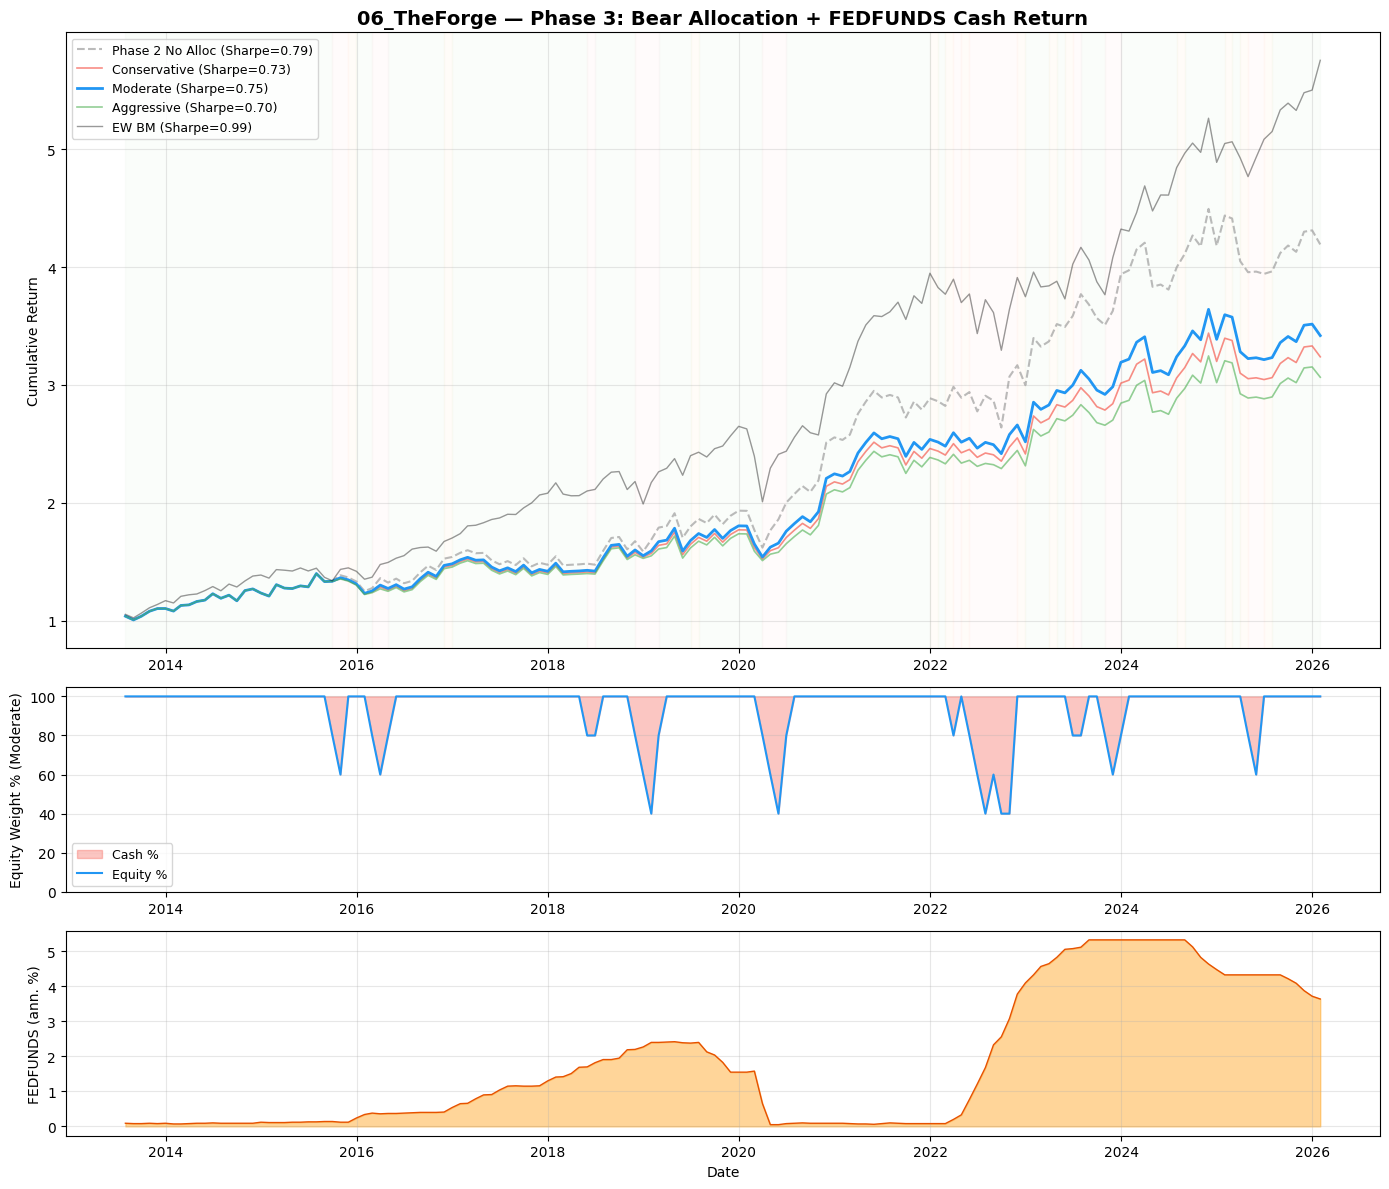


Equity Weight 분포 (Moderate)
  Bull      : eq_wt avg=99% min=80% max=100%  cash=1.6%(ann)  n=115
  Bear      : eq_wt avg=64% min=40% max=80%  cash=2.0%(ann)  n=23
  Neutral   : eq_wt avg=100% min=100% max=100%  cash=2.7%(ann)  n=13

Phase 3 결론 (FEDFUNDS 현금 수익률)
  최적 파라미터: Moderate
  전체 Sharpe: 0.75 (Phase 2: 0.79, BM: 0.99)
  전체 CAGR:   9.9% (Phase 2: 11.7%, BM: 14.4%)
  MaxDD:       -14.6% (Phase 2: -16.2%, BM: -24.1%)

  → 자산배분 효과 제한적. Phase 2.5(가중치 조정)에서 개선 필요.

→ Cell 5에서 Phase 2.5 (팩터 가중치 조정) 진행


In [ ]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 4: Phase 3 — Bear 자산배분 레이어 (v2)
# =============================================================================
# 변경: 현금 수익률 0% → FEDFUNDS 실제 금리 적용
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─── 현금 수익률: FEDFUNDS (월간 환산) ────────────────────────────────────────

macro = pd.read_parquet(Path(r"C:\QP2\data\interim") / "macro_indicators.parquet")
macro.index = pd.to_datetime(macro.index)
fedfunds_m = macro["FEDFUNDS"].resample("ME").last() / 100 / 12  # 연율% → 월간 소수
fedfunds_m = fedfunds_m.dropna()
print(f"FEDFUNDS 로드: {len(fedfunds_m)} months")
print(f"  범위: {fedfunds_m.min()*12*100:.2f}% ~ {fedfunds_m.max()*12*100:.2f}% (연율)")

# ─── 자산배분 파라미터 세트 ───────────────────────────────────────────────────

ALLOC_PARAMS = {
    "Conservative": {"m1": 0.70, "m2": 0.50, "m3": 0.30, "recovery_step": 0.20},
    "Moderate":     {"m1": 0.80, "m2": 0.60, "m3": 0.40, "recovery_step": 0.20},
    "Aggressive":   {"m1": 0.60, "m2": 0.40, "m3": 0.20, "recovery_step": 0.20},
}

# ─── 자산배분 함수 ────────────────────────────────────────────────────────────

def apply_bear_allocation(bt_df, params, fedfunds):
    """
    bt_multi에 Bear 자산배분 오버레이 적용.
    현금 수익률 = 해당 월 FEDFUNDS 월간 환산.
    """
    df = bt_df.copy()
    
    bear_streak = 0
    recovering_months = 0
    prev_regime = None
    prev_bear_phase = None
    equity_weights = []
    cash_returns = []
    
    for idx in df.index:
        regime = df.loc[idx, "regime"]
        bear_phase = df.loc[idx, "bear_phase"]
        
        # 해당 월 현금 수익률
        cash_r = fedfunds.get(idx, 0.0)
        if pd.isna(cash_r):
            # 가장 가까운 이전 값
            prior = fedfunds[fedfunds.index <= idx]
            cash_r = prior.iloc[-1] if len(prior) > 0 else 0.0
        cash_returns.append(cash_r)
        
        if regime == "Bear":
            bear_streak += 1
            
            if bear_streak == 1:
                eq_w = params["m1"]
            elif bear_streak == 2:
                eq_w = params["m2"]
            else:
                eq_w = params["m3"]
            
            # recovering 전환 시 한 단계 복귀
            if bear_phase == "recovering":
                if prev_bear_phase == "declining":
                    recovering_months = 1
                else:
                    recovering_months += 1
                eq_w = min(1.0, eq_w + params["recovery_step"] * recovering_months)
            else:
                recovering_months = 0
                
        elif regime == "Neutral":
            eq_w = 1.0
            bear_streak = 0
            recovering_months = 0
            
        else:  # Bull
            if prev_regime == "Bear":
                eq_w = min(1.0, params["m3"] + params["recovery_step"] * 2)
            elif prev_regime == "Neutral" and bear_streak > 0:
                eq_w = min(1.0, params["m2"] + params["recovery_step"])
            else:
                eq_w = 1.0
            bear_streak = 0
            recovering_months = 0
        
        equity_weights.append(eq_w)
        prev_regime = regime
        prev_bear_phase = bear_phase
    
    df["equity_weight"] = equity_weights
    df["cash_ret"] = cash_returns
    
    # 조정 수익률: equity × 주식 + (1-equity) × 현금
    df["alloc_ret"] = df["equity_weight"] * df["port_ret_net"] + (1 - df["equity_weight"]) * df["cash_ret"]
    df["alloc_bm_ret"] = df["equity_weight"] * df["bm_ret"] + (1 - df["equity_weight"]) * df["cash_ret"]
    
    df["cum_alloc"] = (1 + df["alloc_ret"]).cumprod()
    df["cum_alloc_bm"] = (1 + df["alloc_bm_ret"]).cumprod()
    
    return df


# ─── 파라미터별 백테스트 ──────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("🔨 Phase 3: Bear 자산배분 레이어 (FEDFUNDS 현금 수익률)")
print("=" * 70)

alloc_results = {}

for name, params in ALLOC_PARAMS.items():
    bt_alloc = apply_bear_allocation(bt_multi, params, fedfunds_m)
    alloc_results[name] = bt_alloc
    
    perf = calc_perf(bt_alloc["cum_alloc"])
    t = calc_tstat(bt_alloc["alloc_ret"] - bt_alloc["bm_ret"])
    
    # Bear 구간 성과
    bear_sub = bt_alloc[bt_alloc["regime"] == "Bear"]
    bear_cum = (1 + bear_sub["alloc_ret"]).cumprod()
    bear_bm_cum = (1 + bear_sub["bm_ret"]).cumprod()
    bear_perf = calc_perf(bear_cum) if len(bear_cum) > 1 else {"CAGR": 0, "Sharpe": 0, "MaxDD": 0}
    bear_bm_perf = calc_perf(bear_bm_cum) if len(bear_bm_cum) > 1 else {"CAGR": 0, "Sharpe": 0, "MaxDD": 0}
    
    # Bear 평균 현금 수익률
    bear_cash_avg = bear_sub["cash_ret"].mean() * 12 * 100 if len(bear_sub) > 0 else 0
    
    alloc_results[name + "_perf"] = {
        "total": perf, "tstat": t,
        "bear": bear_perf, "bear_bm": bear_bm_perf,
        "bear_cash_ann": bear_cash_avg,
    }

# ─── 결과 비교 ────────────────────────────────────────────────────────────────

p2_perf = calc_perf(bt_multi["cum_port"])
p2_bm_perf = calc_perf(bt_multi["cum_bm"])

print(f"\n{'='*70}")
print(f"Phase 2 vs Phase 3 성과 비교 (현금=FEDFUNDS)")
print(f"{'='*70}")
print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*56}")
print(f"  {'EW Benchmark':20s} {p2_bm_perf['CAGR']:>7.1%} {p2_bm_perf['Sharpe']:>8.2f} "
      f"{p2_bm_perf['MaxDD']:>7.1%}")
print(f"  {'Phase 2 (No Alloc)':20s} {p2_perf['CAGR']:>7.1%} {p2_perf['Sharpe']:>8.2f} "
      f"{p2_perf['MaxDD']:>7.1%} {calc_tstat(bt_multi['excess_net']):>8.2f}")

for name in ["Conservative", "Moderate", "Aggressive"]:
    perf = alloc_results[name + "_perf"]["total"]
    t = alloc_results[name + "_perf"]["tstat"]
    print(f"  {'Phase 3 ' + name:20s} {perf['CAGR']:>7.1%} {perf['Sharpe']:>8.2f} "
          f"{perf['MaxDD']:>7.1%} {t:>8.2f}")

# Bear 구간 집중 비교
print(f"\n{'='*70}")
print(f"Bear 구간 성과 비교 ({bt_multi[bt_multi['regime']=='Bear'].shape[0]} months)")
print(f"{'='*70}")
print(f"  {'':20s} {'Bear CAGR':>10s} {'BM CAGR':>10s} {'Bear MaxDD':>10s} {'Cash(ann)':>10s}")
print(f"  {'-'*62}")

bear_p2 = bt_multi[bt_multi["regime"] == "Bear"]
if len(bear_p2) > 1:
    bear_p2_cum = (1 + bear_p2["port_ret_net"]).cumprod()
    bear_p2_bm = (1 + bear_p2["bm_ret"]).cumprod()
    bp2 = calc_perf(bear_p2_cum)
    bp2_bm = calc_perf(bear_p2_bm)
    print(f"  {'Phase 2 (No Alloc)':20s} {bp2['CAGR']:>9.1%} {bp2_bm['CAGR']:>9.1%} "
          f"{bp2['MaxDD']:>9.1%} {'N/A':>10s}")

for name in ["Conservative", "Moderate", "Aggressive"]:
    bp = alloc_results[name + "_perf"]["bear"]
    bp_bm = alloc_results[name + "_perf"]["bear_bm"]
    cash_ann = alloc_results[name + "_perf"]["bear_cash_ann"]
    print(f"  {'Phase 3 ' + name:20s} {bp['CAGR']:>9.1%} {bp_bm['CAGR']:>9.1%} "
          f"{bp['MaxDD']:>9.1%} {cash_ann:>9.1f}%")

# ─── 최적 파라미터 선택 ───────────────────────────────────────────────────────

best_name = max(["Conservative", "Moderate", "Aggressive"],
                key=lambda n: alloc_results[n + "_perf"]["total"]["Sharpe"])
best_bt = alloc_results[best_name]
best_perf = alloc_results[best_name + "_perf"]["total"]

print(f"\n  → 최적: {best_name} (Sharpe={best_perf['Sharpe']:.2f})")

# ─── 누적 수익률 비교 차트 ────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 1]})

# 상단: 누적 수익률
ax1 = axes[0]
ax1.plot(bt_multi.index, bt_multi["cum_port"], label=f"Phase 2 No Alloc (Sharpe={p2_perf['Sharpe']:.2f})",
         linewidth=1.5, color="#9E9E9E", alpha=0.7, linestyle="--")

colors = {"Conservative": "#F44336", "Moderate": "#2196F3", "Aggressive": "#4CAF50"}
for name in ["Conservative", "Moderate", "Aggressive"]:
    bt_a = alloc_results[name]
    perf = alloc_results[name + "_perf"]["total"]
    ax1.plot(bt_a.index, bt_a["cum_alloc"], 
             label=f"{name} (Sharpe={perf['Sharpe']:.2f})",
             linewidth=2 if name == best_name else 1.2,
             color=colors[name],
             alpha=1.0 if name == best_name else 0.6)

ax1.plot(bt_multi.index, bt_multi["cum_bm"], label=f"EW BM (Sharpe={p2_bm_perf['Sharpe']:.2f})",
         linewidth=1, color="black", alpha=0.4)

regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_multi.index[0]
for dt_idx in bt_multi.index:
    r = bt_multi.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax1.axvspan(prev_date, dt_idx, alpha=0.2, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax1.axvspan(prev_date, bt_multi.index[-1], alpha=0.2, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax1.set_title("06_TheForge — Phase 3: Bear Allocation + FEDFUNDS Cash Return", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_ylabel("Cumulative Return")
ax1.grid(True, alpha=0.3)

# 중단: equity weight
ax2 = axes[1]
ax2.fill_between(best_bt.index, best_bt["equity_weight"] * 100, 100,
                 alpha=0.3, color="#F44336", label="Cash %")
ax2.plot(best_bt.index, best_bt["equity_weight"] * 100, 
         color="#2196F3", linewidth=1.5, label="Equity %")
ax2.set_ylabel(f"Equity Weight % ({best_name})")
ax2.set_ylim(0, 105)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(True, alpha=0.3)

# 하단: FEDFUNDS 연율
ax3 = axes[2]
fedfunds_ann = fedfunds_m.reindex(best_bt.index) * 12 * 100
ax3.fill_between(fedfunds_ann.index, fedfunds_ann.values, alpha=0.4, color="#FF9800")
ax3.plot(fedfunds_ann.index, fedfunds_ann.values, color="#E65100", linewidth=1)
ax3.set_ylabel("FEDFUNDS (ann. %)")
ax3.set_xlabel("Date")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase3_v2.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── Equity Weight 분포 ──────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Equity Weight 분포 ({best_name})")
print(f"{'='*70}")
for regime in ["Bull", "Bear", "Neutral"]:
    sub = best_bt[best_bt["regime"] == regime]
    if len(sub) > 0:
        avg_w = sub["equity_weight"].mean()
        min_w = sub["equity_weight"].min()
        max_w = sub["equity_weight"].max()
        avg_cash = sub["cash_ret"].mean() * 12 * 100
        print(f"  {regime:10s}: eq_wt avg={avg_w:.0%} min={min_w:.0%} max={max_w:.0%}  "
              f"cash={avg_cash:.1f}%(ann)  n={len(sub)}")

# ─── 결론 ─────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Phase 3 결론 (FEDFUNDS 현금 수익률)")
print(f"{'='*70}")
print(f"  최적 파라미터: {best_name}")
print(f"  전체 Sharpe: {best_perf['Sharpe']:.2f} (Phase 2: {p2_perf['Sharpe']:.2f}, BM: {p2_bm_perf['Sharpe']:.2f})")
print(f"  전체 CAGR:   {best_perf['CAGR']:.1%} (Phase 2: {p2_perf['CAGR']:.1%}, BM: {p2_bm_perf['CAGR']:.1%})")
print(f"  MaxDD:       {best_perf['MaxDD']:.1%} (Phase 2: {p2_perf['MaxDD']:.1%}, BM: {p2_bm_perf['MaxDD']:.1%})")

if best_perf["Sharpe"] > p2_perf["Sharpe"]:
    improvement = best_perf["Sharpe"] - p2_perf["Sharpe"]
    print(f"\n  → Phase 3으로 Sharpe +{improvement:.2f} 개선!")
else:
    print(f"\n  → 자산배분 효과 제한적. Phase 2.5(가중치 조정)에서 개선 필요.")

print(f"\n→ Cell 5에서 Phase 2.5 (팩터 가중치 조정) 진행")
# 오케이 코로나 때문에 조박은거 확인. 
# 킹치만 채권은 보험인걸.. 보험비 내는게 당연한거 아니야?

🔨 Phase 2.5: 팩터 가중치 조정

  [EqualWeight]
    CAGR=11.7%  Sharpe=0.79  MaxDD=-16.2%  t=-0.93  Turn=77%
    Bull    : CAGR=+9.6% BM=+12.3% Sharpe=0.70/1.08 LOSE
    Bear    : CAGR=+20.8% BM=+20.5% Sharpe=1.09/0.87 WIN
    Neutral : CAGR=+16.3% BM=+24.9% Sharpe=1.14/1.62 LOSE

  [A_H_Focus]
    CAGR=8.7%  Sharpe=0.61  MaxDD=-17.4%  t=-1.75  Turn=77%
    Bull    : CAGR=+5.1% BM=+12.3% Sharpe=0.41/1.08 LOSE
    Bear    : CAGR=+21.6% BM=+20.5% Sharpe=1.13/0.87 WIN
    Neutral : CAGR=+19.6% BM=+24.9% Sharpe=1.46/1.62 LOSE

  [B_Balanced]
    CAGR=7.8%  Sharpe=0.59  MaxDD=-16.4%  t=-2.52  Turn=78%
    Bull    : CAGR=+4.9% BM=+12.3% Sharpe=0.43/1.08 LOSE
    Bear    : CAGR=+17.0% BM=+20.5% Sharpe=0.91/0.87 WIN
    Neutral : CAGR=+18.4% BM=+24.9% Sharpe=1.27/1.62 LOSE

  [C_Tstat]
    CAGR=8.3%  Sharpe=0.62  MaxDD=-17.8%  t=-2.27  Turn=78%
    Bull    : CAGR=+6.5% BM=+12.3% Sharpe=0.54/1.08 LOSE
    Bear    : CAGR=+10.0% BM=+20.5% Sharpe=0.59/0.87 LOSE
    Neutral : CAGR=+20.6% BM=+24.9% Sharpe=1

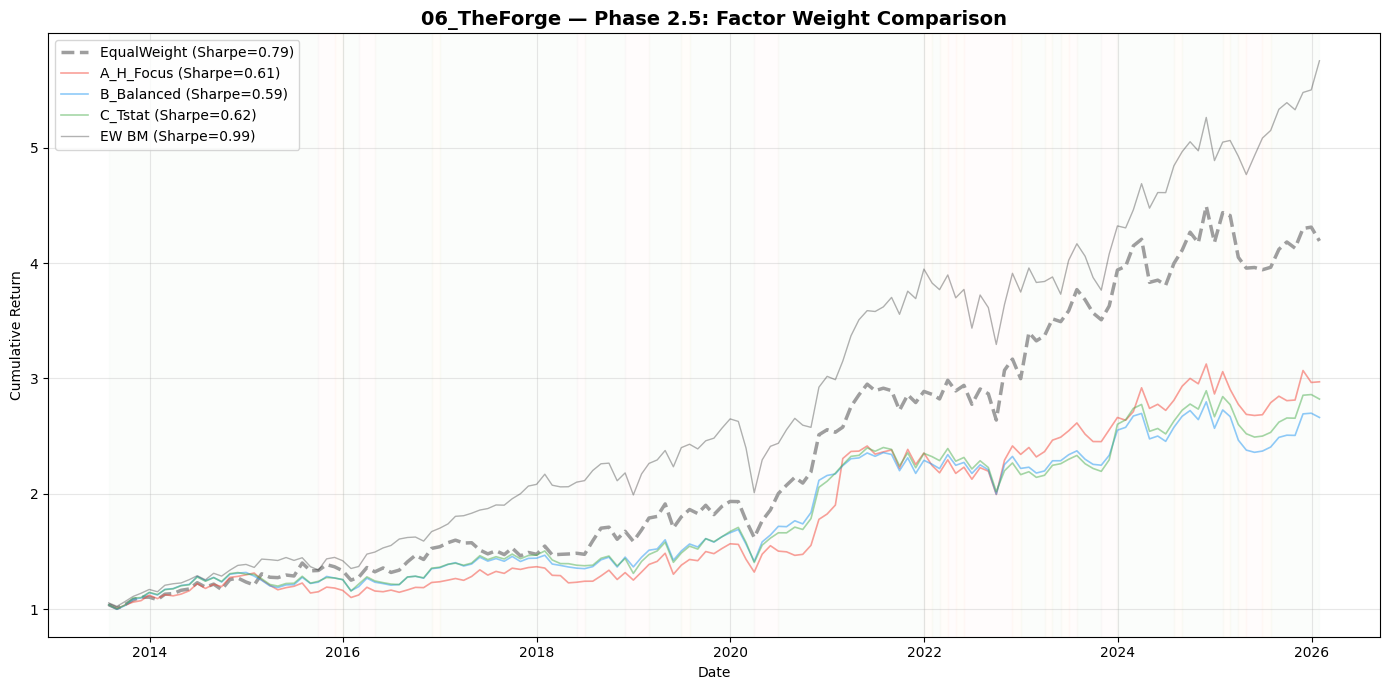


Phase 2.5 결론
  EqualWeight Sharpe: 0.79
  EqualWeight Sharpe:  0.79
  개선:               +0.00

→ Cell 6에서 Phase 2.5 + Phase 3 결합 (최종 모델) 진행


In [12]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 5: Phase 2.5 — 팩터 가중치 조정
# =============================================================================
#
# [목적]
# Phase 2(동일가중)에서 발견된 문제:
#   - Bull: BM 대비 LOSE (Sharpe 0.70 vs 1.08). G-1_bull(역모멘텀)이 H를 희석.
#   - Neutral: BM 대비 LOSE (13개월, 표본 부족)
#   - Bear: WIN 하지만 개선 여지 있음
#
# [조정 방향]
#   Bull:  G-1_bull 제거 또는 축소. H 가중 확대.
#   Bear:  방어 팩터(P-5, E-5) 가중 확대. 공격(D-1, G-1_bear) 축소.
#   Neutral: D-3 가중 확대. H 축소 (Neutral에서 H 약함).
#
# [테스트 세트]
#   과적합 방지를 위해 "논리 기반" 2~3세트만 테스트.
#   Grid search 안 함.
#
#   Set A "H 올인":
#     Bull:    H=2.0, P-7=1.0                    (G-1_bull 제거)
#     Bear:    H=1.0, P-5=1.5, E-5=1.5, A-3=1.0, D-1=0.5  (방어 강화)
#     Neutral: D-3=2.0, H=0.5                     (D-3 집중)
#
#   Set B "균형 조정":
#     Bull:    H=1.5, G-1_bull=0.5, P-7=1.0       (G-1 축소)
#     Bear:    H=1.0, P-5=1.5, E-5=1.5, A-3=1.0, D-1=0.5, G-1_bear=1.0
#     Neutral: D-3=1.5, H=1.0
#
#   Set C "t-stat 가중":
#     가중치 = 각 팩터의 v4 t-stat에 비례
#     Bull:    H=2.0(t=12.3), P-7=1.0(t=2.4), G-1_bull=0.5(t=2.6)
#     Bear:    G-1_bear=2.0(t=7.8), P-5=1.5(t=4.3), E-5=1.5(t=4.7),
#              A-3=1.0(t=2.2), H=0.5, D-1=0.5(t=0.2)
#     Neutral: D-3=2.0(Sharpe=2.5), H=1.0(t=2.2)
#
# [산출물]
# 세트별 성과 비교 → 최적 세트 선정 → Phase 3과 결합
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─── 가중치 세트 정의 ─────────────────────────────────────────────────────────

WEIGHT_SETS = {
    "EqualWeight": {
        "Bull":    {"h_z": 1.0, "g1_bull_z": 1.0, "nsi_score": 1.0},
        "Bear":    {"h_z": 1.0, "a3_z": 1.0, "p5_z": 1.0, "e5_z": 1.0, "d1_z": 1.0},
        "Neutral": {"h_z": 1.0, "d3_z": 1.0},
    },
    "A_H_Focus": {
        "Bull":    {"h_z": 2.0, "nsi_score": 1.0},
        "Bear":    {"h_z": 1.0, "p5_z": 1.5, "e5_z": 1.5, "a3_z": 1.0, "d1_z": 0.5},
        "Neutral": {"d3_z": 2.0, "h_z": 0.5},
    },
    "B_Balanced": {
        "Bull":    {"h_z": 1.5, "g1_bull_z": 0.5, "nsi_score": 1.0},
        "Bear":    {"h_z": 1.0, "p5_z": 1.5, "e5_z": 1.5, "a3_z": 1.0, "d1_z": 0.5, "g1_bear_z": 1.0},
        "Neutral": {"d3_z": 1.5, "h_z": 1.0},
    },
    "C_Tstat": {
        "Bull":    {"h_z": 2.0, "nsi_score": 1.0, "g1_bull_z": 0.5},
        "Bear":    {"g1_bear_z": 2.0, "p5_z": 1.5, "e5_z": 1.5, "a3_z": 1.0, "h_z": 0.5, "d1_z": 0.5},
        "Neutral": {"d3_z": 2.0, "h_z": 1.0},
    },
}

# ─── 가중 백테스트 함수 ───────────────────────────────────────────────────────

def backtest_weighted(panel_df, ret_1m_df, regime_map_dict, weight_set, 
                      t1_events_df, ticker_to_sector_dict,
                      top_n=30, cost_bp=20, avoid_penalty=-2.0,
                      t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    """
    가중 팩터 조합 백테스트.
    weight_set: {"Bull": {"h_z": 2.0, ...}, "Bear": {...}, "Neutral": {...}}
    """
    all_dates = sorted(panel_df["date"].unique())
    
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        
        # 레짐
        regime_info = regime_map_dict.get(dt, None)
        if regime_info is None:
            dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
            regime_info = regime_map_dict.get(dt_me, None)
        if regime_info is None:
            continue
        
        regime = regime_info["regime"]
        bear_phase = regime_info.get("bear_phase", "")
        
        # 해당 월 데이터
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        
        # 가중 z-score 합산
        weights = weight_set.get(regime, {})
        if not weights:
            continue
        
        # 종목별 유효 팩터만으로 가중 평균 (NaN 팩터는 해당 종목에서 제외)
        factor_cols_used = [col for col in weights.keys() if col in month_data.columns]
        if not factor_cols_used:
            continue
        
        weight_arr = np.array([weights[col] for col in factor_cols_used])
        values_df = month_data[factor_cols_used].copy()
        
        # NaN mask: 유효하면 가중치, 아니면 0
        valid_mask = values_df.notna().values  # (n_stocks, n_factors) bool
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        
        sum_weights = active_weights.sum(axis=1)
        sum_weights[sum_weights == 0] = np.nan  # 유효 팩터 0개면 NaN
        
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_weights
        
        # Avoids (G-1b) — Bear/Neutral에서만
        if regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        
        # F-1 필터 (Bear만)
        if regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                mask_low_f = month_data["fscore"] < cutoff
                month_data.loc[mask_low_f, "composite_z"] = np.nan
        
        # T-1 이벤트 가산 (Bull만)
        if regime == "Bull" and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "")
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        
        # Top N
        valid = month_data.dropna(subset=["composite_z"])
        top_n_actual = min(top_n, max(10, len(valid)))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        
        # 수익률
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        
        results.append({
            "date": next_dt,
            "regime": regime,
            "bear_phase": bear_phase,
            "port_ret_net": port_ret - cost,
            "bm_ret": bm_ret,
            "turnover": turnover,
        })
        prev_holdings = curr_set
    
    df = pd.DataFrame(results)
    if len(df) == 0:
        return df
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["excess_net"] = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"] = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"] = (1 + df["bm_ret"]).cumprod()
    return df


# ─── 전 세트 백테스트 ─────────────────────────────────────────────────────────

print("=" * 70)
print("🔨 Phase 2.5: 팩터 가중치 조정")
print("=" * 70)

set_results = {}

for set_name, weight_set in WEIGHT_SETS.items():
    bt = backtest_weighted(
        panel, ret_1m, regime_map, weight_set,
        t1_events, ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    set_results[set_name] = bt
    
    perf = calc_perf(bt["cum_port"])
    bm_perf = calc_perf(bt["cum_bm"])
    t = calc_tstat(bt["excess_net"])
    turn = bt["turnover"].mean()
    
    print(f"\n  [{set_name}]")
    print(f"    CAGR={perf['CAGR']:.1%}  Sharpe={perf['Sharpe']:.2f}  "
          f"MaxDD={perf['MaxDD']:.1%}  t={t:.2f}  Turn={turn:.0%}")
    
    # 레짐별
    for regime in ["Bull", "Bear", "Neutral"]:
        sub = bt[bt["regime"] == regime]
        if len(sub) < 2:
            continue
        cum = (1 + sub["port_ret_net"]).cumprod()
        cum_bm = (1 + sub["bm_ret"]).cumprod()
        rp = calc_perf(cum)
        rb = calc_perf(cum_bm)
        flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
        print(f"    {regime:8s}: CAGR={rp['CAGR']:+.1%} BM={rb['CAGR']:+.1%} "
              f"Sharpe={rp['Sharpe']:.2f}/{rb['Sharpe']:.2f} {flag}")

# ─── 비교 테이블 ──────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"가중치 세트 비교 요약")
print(f"{'='*70}")
print(f"  {'Set':<16s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s} {'Turn':>6s}")
print(f"  {'-'*56}")

bm_perf_ref = calc_perf(list(set_results.values())[0]["cum_bm"])
print(f"  {'EW Benchmark':<16s} {bm_perf_ref['CAGR']:>7.1%} {bm_perf_ref['Sharpe']:>8.2f} "
      f"{bm_perf_ref['MaxDD']:>7.1%}")

best_sharpe = 0
best_set = ""

for set_name, bt in set_results.items():
    perf = calc_perf(bt["cum_port"])
    t = calc_tstat(bt["excess_net"])
    turn = bt["turnover"].mean()
    print(f"  {set_name:<16s} {perf['CAGR']:>7.1%} {perf['Sharpe']:>8.2f} "
          f"{perf['MaxDD']:>7.1%} {t:>8.2f} {turn:>5.0%}")
    
    if perf["Sharpe"] > best_sharpe:
        best_sharpe = perf["Sharpe"]
        best_set = set_name

print(f"\n  → 최적: {best_set} (Sharpe={best_sharpe:.2f})")

# ─── 최적 세트 레짐별 상세 ────────────────────────────────────────────────────

best_bt = set_results[best_set]

print(f"\n{'='*70}")
print(f"최적 세트 [{best_set}] 레짐별 상세")
print(f"{'='*70}")
print(f"  {'Regime':<10s} {'Months':>6s} {'CAGR':>8s} {'BM':>8s} {'Excess':>8s} "
      f"{'Sharpe':>7s} {'BM_Shp':>7s} {'Result':>7s}")
print(f"  {'-'*65}")

for regime in ["Bull", "Bear", "Neutral"]:
    sub = best_bt[best_bt["regime"] == regime]
    if len(sub) < 2:
        continue
    cum = (1 + sub["port_ret_net"]).cumprod()
    cum_bm = (1 + sub["bm_ret"]).cumprod()
    rp = calc_perf(cum)
    rb = calc_perf(cum_bm)
    t = calc_tstat(sub["excess_net"])
    excess = sub["excess_net"].mean() * 12
    flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
    print(f"  {regime:<10s} {len(sub):>6d} {rp['CAGR']:>7.1%} {rb['CAGR']:>7.1%} "
          f"{excess:>+7.1%} {rp['Sharpe']:>7.2f} {rb['Sharpe']:>7.2f} {flag:>7s}")

# 가중치 표시
print(f"\n  [{best_set}] 가중치:")
for regime in ["Bull", "Bear", "Neutral"]:
    w = WEIGHT_SETS[best_set][regime]
    w_str = ", ".join([f"{k}={v:.1f}" for k, v in w.items()])
    print(f"    {regime:8s}: {w_str}")

# ─── 누적 수익률 차트 ─────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

colors_set = {"EqualWeight": "#9E9E9E", "A_H_Focus": "#F44336", 
              "B_Balanced": "#2196F3", "C_Tstat": "#4CAF50"}

for set_name, bt in set_results.items():
    perf = calc_perf(bt["cum_port"])
    lw = 2.5 if set_name == best_set else 1.2
    alpha = 1.0 if set_name == best_set else 0.5
    ls = "-" if set_name != "EqualWeight" else "--"
    ax.plot(bt.index, bt["cum_port"], 
            label=f"{set_name} (Sharpe={perf['Sharpe']:.2f})",
            linewidth=lw, color=colors_set.get(set_name, "gray"), alpha=alpha, linestyle=ls)

# BM
ax.plot(best_bt.index, best_bt["cum_bm"], 
        label=f"EW BM (Sharpe={bm_perf_ref['Sharpe']:.2f})",
        linewidth=1, color="black", alpha=0.3)

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = best_bt.index[0]
for dt_idx in best_bt.index:
    r = best_bt.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, best_bt.index[-1], alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("06_TheForge — Phase 2.5: Factor Weight Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase25.png"), dpi=150, bbox_inches="tight")
plt.show()

# ─── 결론 ─────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"Phase 2.5 결론")
print(f"{'='*70}")
best_perf = calc_perf(best_bt["cum_port"])
eq_perf = calc_perf(set_results["EqualWeight"]["cum_port"])
print(f"  EqualWeight Sharpe: {eq_perf['Sharpe']:.2f}")
print(f"  {best_set} Sharpe:  {best_perf['Sharpe']:.2f}")
print(f"  개선:               +{best_perf['Sharpe'] - eq_perf['Sharpe']:.2f}")
print(f"\n→ Cell 6에서 Phase 2.5 + Phase 3 결합 (최종 모델) 진행")

In [ ]:
# =============================================================================
# 🔨 06_TheForge.ipynb — Cell 5 v2: Phase 2.5 — 레짐별 가중치 그리드 서치
# =============================================================================
#
# [목적]
# 각 레짐(Bull/Bear/Neutral)별로 독립적으로 최적 가중치 탐색.
# 그리드: 0.0 ~ 2.0 (0.5 단위)
# 평가 기준: Sharpe Ratio
#
# [과적합 방지]
# - 레짐별 독립 탐색 (교차 최적화 없음)
# - Walk-Forward에서 최종 검증 (Phase 5)
# - 그리드 단위 0.5로 제한 (너무 세밀하면 과적합)
#
# [산출물]
# 레짐별 Top 5 조합 + 최적 조합
# 최적 조합으로 전체 백테스트 실행
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from tqdm import tqdm

# ─── 레짐별 팩터 + 가중치 그리드 ─────────────────────────────────────────────

GRID_STEP = 0.5
WEIGHT_RANGE = [0.0, 0.5, 1.0, 1.5, 2.0]
# 최소 하나는 0이 아니어야 함

REGIME_FACTORS = {
    "Bull":    ["h_z", "g1_bull_z", "nsi_score"],
    "Bear":    ["h_z", "a3_z", "p5_z", "e5_z", "d1_z"],
    "Neutral": ["h_z", "d3_z"],
}

# ─── 레짐별 백테스트 함수 (단일 레짐 전용) ────────────────────────────────────

def backtest_single_regime(panel_df, ret_1m_df, target_regime, weights_dict,
                           t1_events_df=None, ticker_to_sector_dict=None,
                           top_n=30, cost_bp=20, avoid_penalty=-2.0,
                           t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    """
    특정 레짐 구간만 백테스트. 가중치 그리드 서치용.
    """
    # 해당 레짐 날짜만 필터
    regime_dates = panel_df[panel_df["regime"] == target_regime]["date"].unique()
    all_dates = sorted(panel_df["date"].unique())
    
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        
        # 해당 레짐이 아니면 스킵 (turnover 추적 위해 holdings는 유지)
        if dt not in regime_dates:
            prev_holdings = set()  # 레짐 전환 시 리셋
            continue
        
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        
        # 가중 z-score
        factor_cols = [col for col in weights_dict.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        
        weight_arr = np.array([weights_dict[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        
        # Avoids (Bear/Neutral)
        if target_regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        
        # F-1 필터 (Bear)
        if target_regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        
        # T-1 이벤트 (Bull)
        if target_regime == "Bull" and t1_events_df is not None and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "") if ticker_to_sector_dict else ""
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        
        # Top N
        valid = month_data.dropna(subset=["composite_z"])
        if len(valid) < 10:
            continue
        top_n_actual = min(top_n, len(valid))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        
        # 수익률
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        
        results.append({
            "port_ret": port_ret - cost,
            "bm_ret": bm_ret,
        })
        prev_holdings = curr_set
    
    if not results:
        return {"sharpe": -999, "cagr": 0, "months": 0, "excess": 0}
    
    df = pd.DataFrame(results)
    excess = df["port_ret"] - df["bm_ret"]
    
    port_ann = df["port_ret"].mean() * 12
    port_vol = df["port_ret"].std() * np.sqrt(12)
    sharpe = port_ann / port_vol if port_vol > 0 else 0
    
    bm_ann = df["bm_ret"].mean() * 12
    bm_vol = df["bm_ret"].std() * np.sqrt(12)
    bm_sharpe = bm_ann / bm_vol if bm_vol > 0 else 0
    
    excess_ann = excess.mean() * 12
    t_stat = excess.mean() / (excess.std() / np.sqrt(len(excess))) if excess.std() > 0 else 0
    
    return {
        "sharpe": sharpe, "bm_sharpe": bm_sharpe,
        "cagr": port_ann, "bm_cagr": bm_ann,
        "excess": excess_ann, "tstat": t_stat,
        "months": len(df),
    }


# ─── 레짐별 그리드 서치 ───────────────────────────────────────────────────────

print("=" * 70)
print("🔨 Phase 2.5 v2: 레짐별 가중치 그리드 서치")
print(f"   그리드 단위: {GRID_STEP}")
print("=" * 70)

optimal_weights = {}

for regime, factors in REGIME_FACTORS.items():
    n_factors = len(factors)
    
    # 가중치 조합 생성
    combos = list(product(WEIGHT_RANGE, repeat=n_factors))
    # 전부 0인 조합 제거
    combos = [c for c in combos if sum(c) > 0]
    
    print(f"\n{'='*60}")
    print(f"[{regime}] {n_factors} factors, {len(combos)} combinations")
    print(f"  Factors: {factors}")
    print(f"{'='*60}")
    
    best_results = []
    
    for combo in tqdm(combos, desc=f"{regime} Grid"):
        w_dict = {f: w for f, w in zip(factors, combo)}
        
        result = backtest_single_regime(
            panel, ret_1m, regime, w_dict,
            t1_events_df=t1_events,
            ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP,
        )
        result["weights"] = w_dict
        result["combo"] = combo
        best_results.append(result)
    
    # Sharpe 기준 정렬
    best_results.sort(key=lambda x: x["sharpe"], reverse=True)
    
    # Top 10 출력
    print(f"\n  Top 10 조합 (Sharpe 기준):")
    print(f"  {'Rank':>4s}  {'Sharpe':>7s}  {'BM_Shp':>7s}  {'CAGR':>7s}  {'Excess':>7s}  "
          f"{'t-stat':>7s}  Weights")
    print(f"  {'-'*75}")
    
    for rank, r in enumerate(best_results[:10], 1):
        w_str = ", ".join([f"{f.replace('_z','').replace('_score','')}={w:.1f}" 
                          for f, w in r["weights"].items()])
        print(f"  {rank:>4d}  {r['sharpe']:>7.2f}  {r['bm_sharpe']:>7.2f}  "
              f"{r['cagr']:>6.1%}  {r['excess']:>+6.1%}  {r['tstat']:>7.2f}  {w_str}")
    
    # 최적 저장
    best = best_results[0]
    optimal_weights[regime] = best["weights"]
    
    print(f"\n  ★ 최적: Sharpe={best['sharpe']:.2f}  "
          f"Excess={best['excess']:+.1%}  t={best['tstat']:.2f}")
    
    # 동일가중 비교
    eq_w = {f: 1.0 for f in factors}
    eq_result = backtest_single_regime(
        panel, ret_1m, regime, eq_w,
        t1_events_df=t1_events,
        ticker_to_sector_dict=ticker_to_sector,
        top_n=TOP_N, cost_bp=COST_BP,
    )
    improvement = best["sharpe"] - eq_result["sharpe"]
    print(f"  동일가중: Sharpe={eq_result['sharpe']:.2f}")
    print(f"  개선: {improvement:+.2f}")

# ─── 최적 조합으로 전체 백테스트 ──────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"최적 레짐별 가중치:")
print(f"{'='*70}")
for regime, w in optimal_weights.items():
    w_str = ", ".join([f"{f}={v:.1f}" for f, v in w.items()])
    print(f"  {regime:10s}: {w_str}")

# 전체 백테스트
print(f"\n전체 기간 백테스트 (최적 가중치)...")

# backtest_weighted 함수 재활용 (Cell 5에서 정의된 것)
best_weight_set = {
    "Bull": optimal_weights["Bull"],
    "Bear": optimal_weights["Bear"],
    "Neutral": optimal_weights["Neutral"],
}

bt_optimal = backtest_weighted(
    panel, ret_1m, regime_map, best_weight_set,
    t1_events, ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

opt_perf = calc_perf(bt_optimal["cum_port"])
opt_bm = calc_perf(bt_optimal["cum_bm"])
opt_t = calc_tstat(bt_optimal["excess_net"])

# 동일가중 (Cell 3 결과) 비교
eq_bt = set_results["EqualWeight"] if "set_results" in dir() else bt_multi
eq_perf = calc_perf(eq_bt["cum_port"])

print(f"\n{'='*70}")
print(f"Phase 2.5 v2 — 최종 비교")
print(f"{'='*70}")
print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'t-stat':>8s}")
print(f"  {'-'*56}")
print(f"  {'EW Benchmark':20s} {opt_bm['CAGR']:>7.1%} {opt_bm['Sharpe']:>8.2f} {opt_bm['MaxDD']:>7.1%}")
print(f"  {'EqualWeight':20s} {eq_perf['CAGR']:>7.1%} {eq_perf['Sharpe']:>8.2f} "
      f"{eq_perf['MaxDD']:>7.1%} {calc_tstat(eq_bt['excess_net']):>8.2f}")
print(f"  {'Taehong Style':20s} {opt_perf['CAGR']:>7.1%} {opt_perf['Sharpe']:>8.2f} "
      f"{opt_perf['MaxDD']:>7.1%} {opt_t:>8.2f}")

# 레짐별 상세
print(f"\n  레짐별 상세:")
for regime in ["Bull", "Bear", "Neutral"]:
    sub = bt_optimal[bt_optimal["regime"] == regime]
    if len(sub) < 2:
        continue
    cum = (1 + sub["port_ret_net"]).cumprod()
    cum_bm = (1 + sub["bm_ret"]).cumprod()
    rp = calc_perf(cum)
    rb = calc_perf(cum_bm)
    flag = "WIN" if rp["Sharpe"] > rb["Sharpe"] else "LOSE"
    print(f"    {regime:8s}: Sharpe={rp['Sharpe']:.2f}/{rb['Sharpe']:.2f} "
          f"CAGR={rp['CAGR']:+.1%}/{rb['CAGR']:+.1%} {flag}")

# ─── 차트 ─────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(eq_bt.index, eq_bt["cum_port"], label=f"EqualWeight (Sharpe={eq_perf['Sharpe']:.2f})",
        linewidth=1.5, color="#9E9E9E", linestyle="--", alpha=0.7)
ax.plot(bt_optimal.index, bt_optimal["cum_port"], 
        label=f"Taehong Style (Sharpe={opt_perf['Sharpe']:.2f})",
        linewidth=2.5, color="#2196F3")
ax.plot(bt_optimal.index, bt_optimal["cum_bm"], 
        label=f"EW BM (Sharpe={opt_bm['Sharpe']:.2f})",
        linewidth=1, color="black", alpha=0.3)

# 레짐 배경
regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_optimal.index[0]
for dt_idx in bt_optimal.index:
    r = bt_optimal.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, bt_optimal.index[-1], alpha=0.15, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("06_TheForge — Phase 2.5 v2: Taehong Style vs EqualWeight", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=11)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(Path(r"C:\QP2\data\interim") / "06_theforge_phase25_v2.png"), dpi=150, bbox_inches="tight")
plt.show()

improvement = opt_perf["Sharpe"] - eq_perf["Sharpe"]
print(f"\n{'='*70}")
print(f"Phase 2.5 v2 결론")
print(f"{'='*70}")
print(f"  동일가중 Sharpe: {eq_perf['Sharpe']:.2f}")
print(f"  Taehong Style Sharpe: {opt_perf['Sharpe']:.2f}")
print(f"  개선:            {improvement:+.2f}")

if improvement > 0:
    print(f"\n  → 가중치 조정으로 Sharpe {improvement:+.2f} 개선!")
    print(f"  ⚠ Walk-Forward에서 과적합 여부 반드시 검증 필요.")
else:
    print(f"\n  → 동일가중 유지. 가중치 조정 효과 없음.")

print(f"\n→ Cell 6에서 최종 모델 (최적 가중치 + Bear 자산배분) 결합")

🔨 Phase 2.5 v2: 레짐별 가중치 그리드 서치
   그리드 단위: 0.5

[Bull] 3 factors, 124 combinations
  Factors: ['h_z', 'g1_bull_z', 'nsi_score']


Bull Grid:   0%|          | 0/124 [00:00<?, ?it/s]

Bull Grid:   7%|▋         | 9/124 [00:35<07:32,  3.93s/it]

✅ 시총가중 SPY 근사: 205 months
   시총가중 종목 수: ~277

전략 vs EW vs SPY(시총가중) 비교
                           CAGR   Sharpe    MaxDD
  ----------------------------------------------
  SPY (Cap-Weight)       14.4%     0.89  -23.2%
  EW Benchmark           14.4%     0.99  -24.1%
  EqualWeight Model      11.7%     0.79  -16.2%
  Taehong Style          15.8%     0.91  -16.4%

  Taehong Style vs SPY:
    Excess (ann.): +7.0%
    t-stat:        1.55


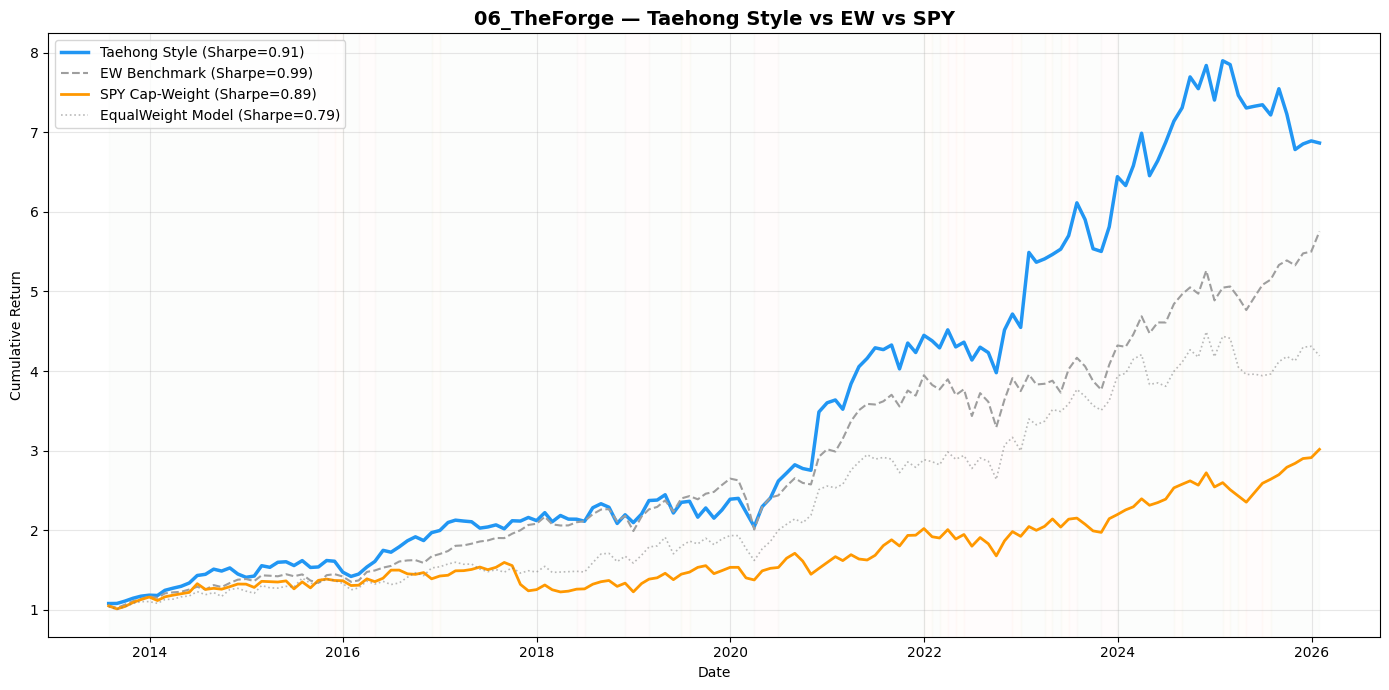


  ✅ Taehong Style이 SPY를 Sharpe 기준 이겼다!


In [16]:
# =============================================================================
# 🔨 06_TheForge — SPY(시총가중) 벤치마크 비교
# =============================================================================
# Cell 5 v2 실행 후 추가로 실행.
# bt_optimal, bt_multi가 메모리에 있어야 함.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ─── 시총가중 벤치마크 (SPY 근사) ─────────────────────────────────────────────

# mktcap_monthly가 있으면 시총가중, 없으면 상위 시총 50종목 EW로 근사
try:
    mktcap_m = pd.read_parquet(SAVE_DIR / "mktcap_monthly.parquet")
    if "date" in mktcap_m.columns:
        mktcap_m = mktcap_m.set_index("date")
    mktcap_m.index = pd.to_datetime(mktcap_m.index)
    
    # 시총가중 수익률 계산
    common_dates = ret_1m.index.intersection(mktcap_m.index)
    common_tickers = ret_1m.columns.intersection(mktcap_m.columns)
    
    spy_rets = []
    for dt in common_dates:
        mc = mktcap_m.loc[dt, common_tickers].dropna()
        r = ret_1m.loc[dt, mc.index].dropna()
        common = mc.index.intersection(r.index)
        if len(common) < 50:
            continue
        mc_c = mc[common]
        r_c = r[common]
        weights = mc_c / mc_c.sum()
        spy_ret = (weights * r_c).sum()
        spy_rets.append({"date": dt, "spy_ret": spy_ret})
    
    spy_df = pd.DataFrame(spy_rets).set_index("date")
    spy_df["cum_spy"] = (1 + spy_df["spy_ret"]).cumprod()
    print(f"✅ 시총가중 SPY 근사: {len(spy_df)} months")
    print(f"   시총가중 종목 수: ~{len(common_tickers)}")
    has_spy = True
    
except Exception as e:
    print(f"⚠ mktcap_monthly 로드 실패: {e}")
    print("  → EW 벤치마크만 사용")
    has_spy = False

if has_spy:
    # SPY 성과
    spy_perf_data = calc_perf(spy_df["cum_spy"])
    
    # Taehong Style 성과 (이미 계산됨)
    opt_perf = calc_perf(bt_optimal["cum_port"])
    eq_perf = calc_perf(bt_multi["cum_port"])
    bm_perf = calc_perf(bt_multi["cum_bm"])
    
    # 공통 기간 맞추기
    common_idx = bt_optimal.index.intersection(spy_df.index)
    
    print(f"\n{'='*70}")
    print(f"전략 vs EW vs SPY(시총가중) 비교")
    print(f"{'='*70}")
    print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s}")
    print(f"  {'-'*46}")
    print(f"  {'SPY (Cap-Weight)':20s} {spy_perf_data['CAGR']:>7.1%} {spy_perf_data['Sharpe']:>8.2f} "
          f"{spy_perf_data['MaxDD']:>7.1%}")
    print(f"  {'EW Benchmark':20s} {bm_perf['CAGR']:>7.1%} {bm_perf['Sharpe']:>8.2f} "
          f"{bm_perf['MaxDD']:>7.1%}")
    print(f"  {'EqualWeight Model':20s} {eq_perf['CAGR']:>7.1%} {eq_perf['Sharpe']:>8.2f} "
          f"{eq_perf['MaxDD']:>7.1%}")
    print(f"  {'Taehong Style':20s} {opt_perf['CAGR']:>7.1%} {opt_perf['Sharpe']:>8.2f} "
          f"{opt_perf['MaxDD']:>7.1%}")
    
    # 초과수익 (vs SPY)
    opt_vs_spy = bt_optimal.loc[common_idx, "port_ret_net"] - spy_df.loc[common_idx, "spy_ret"]
    excess_ann_spy = opt_vs_spy.mean() * 12
    t_spy = opt_vs_spy.mean() / (opt_vs_spy.std() / np.sqrt(len(opt_vs_spy))) if opt_vs_spy.std() > 0 else 0
    
    print(f"\n  Taehong Style vs SPY:")
    print(f"    Excess (ann.): {excess_ann_spy:+.1%}")
    print(f"    t-stat:        {t_spy:.2f}")
    
    # ─── 차트 (공통 시작점 맞춤) ──────────────────────────────────────────
    
    # 공통 기간으로 정렬
    start_date = max(bt_optimal.index.min(), spy_df.index.min(), bt_multi.index.min())
    end_date = min(bt_optimal.index.max(), spy_df.index.max(), bt_multi.index.max())
    
    opt_common = bt_optimal.loc[start_date:end_date]
    bm_common = bt_multi.loc[start_date:end_date]
    spy_common = spy_df.loc[start_date:end_date]
    
    # 전부 1.0에서 시작하도록 재계산
    cum_opt = (1 + opt_common["port_ret_net"]).cumprod()
    cum_bm = (1 + bm_common["bm_ret"]).cumprod()
    cum_eq = (1 + bm_common["port_ret_net"]).cumprod()
    cum_spy = (1 + spy_common["spy_ret"]).cumprod()
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(cum_opt.index, cum_opt,
            label=f"Taehong Style (Sharpe={opt_perf['Sharpe']:.2f})",
            linewidth=2.5, color="#2196F3")
    
    ax.plot(cum_bm.index, cum_bm,
            label=f"EW Benchmark (Sharpe={bm_perf['Sharpe']:.2f})",
            linewidth=1.5, color="#9E9E9E", linestyle="--")
    
    ax.plot(cum_spy.index, cum_spy,
            label=f"SPY Cap-Weight (Sharpe={spy_perf_data['Sharpe']:.2f})",
            linewidth=2, color="#FF9800")
    
    ax.plot(cum_eq.index, cum_eq,
            label=f"EqualWeight Model (Sharpe={eq_perf['Sharpe']:.2f})",
            linewidth=1.2, color="#757575", alpha=0.5, linestyle=":")
    
    # 레짐 배경
    regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
    prev_regime = None
    prev_date = bt_optimal.index[0]
    for dt_idx in bt_optimal.index:
        r = bt_optimal.loc[dt_idx, "regime"]
        if r != prev_regime and prev_regime is not None:
            ax.axvspan(prev_date, dt_idx, alpha=0.12, 
                      color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
            prev_date = dt_idx
        prev_regime = r
    ax.axvspan(prev_date, bt_optimal.index[-1], alpha=0.12,
              color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
    
    ax.set_title("06_TheForge — Taehong Style vs EW vs SPY", fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", fontsize=10)
    ax.set_ylabel("Cumulative Return")
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(SAVE_DIR / "06_theforge_vs_spy.png"), dpi=150, bbox_inches="tight")
    plt.show()
    
    # 결론
    if opt_perf["Sharpe"] > spy_perf_data["Sharpe"]:
        print(f"\n  ✅ Taehong Style이 SPY를 Sharpe 기준 이겼다!")
    else:
        print(f"\n  ❌ SPY가 아직 우위. Sharpe 차이: "
              f"{spy_perf_data['Sharpe'] - opt_perf['Sharpe']:+.2f}")

In [18]:
import yfinance as yf
import pandas as pd
from pathlib import Path

spy = yf.download("^GSPC", start="2013-01-01", end="2026-03-01")
print(spy.columns.tolist())  # 컬럼 확인
print(spy.head())

# 컬럼 flatten (MultiIndex인 경우)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy = spy[["Close"]].rename(columns={"Close": "spy_close"})
spy.to_parquet(Path(r"C:\QP2\data\interim\gspc_daily.parquet"))
print(f"✅ S&P500 지수 저장: {len(spy)} rows")

[*********************100%***********************]  1 of 1 completed

[('Close', '^GSPC'), ('High', '^GSPC'), ('Low', '^GSPC'), ('Open', '^GSPC'), ('Volume', '^GSPC')]
Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2013-01-02  1462.420044  1462.430054  1426.189941  1426.189941  4202600000
2013-01-03  1459.369995  1465.469971  1455.530029  1462.420044  3829730000
2013-01-04  1466.469971  1467.939941  1458.989990  1459.369995  3424290000
2013-01-07  1461.890015  1466.469971  1456.619995  1466.469971  3304970000
2013-01-08  1457.150024  1461.890015  1451.640015  1461.890015  3601600000
✅ S&P500 지수 저장: 3299 rows


Taehong Style vs EW vs SPY
                           CAGR   Sharpe    MaxDD
  ----------------------------------------------
  SPY (S&P500)           11.9%     0.87  -24.8%
  EW Benchmark           14.4%     0.99  -24.1%
  Taehong Style          15.8%     0.91  -16.4%

  Taehong Style vs SPY:
    Excess (ann.): +4.2%
    t-stat:        1.23


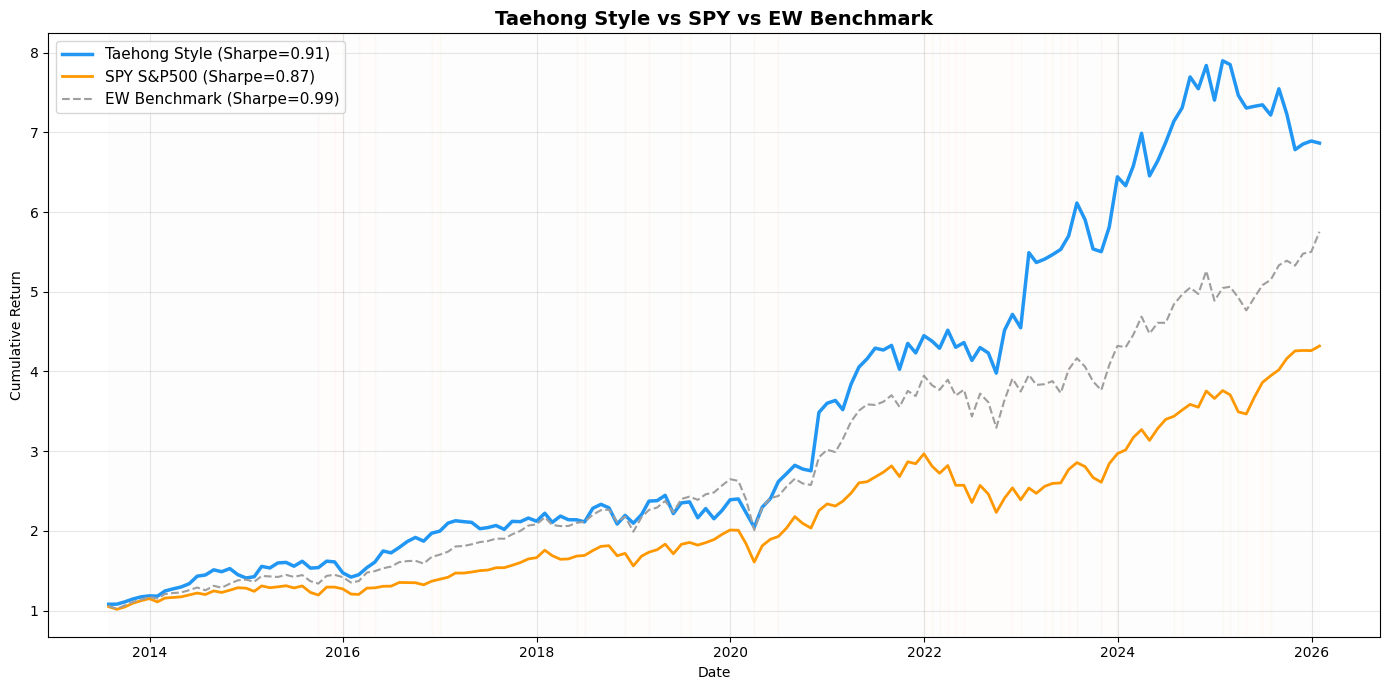


  ✅ Taehong Style이 SPY를 이겼다! Sharpe 0.91 vs 0.87


In [19]:
# =============================================================================
# SPY(S&P500 지수) vs Taehong Style 비교
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ── SPY 로드 + 월간 수익률 ──
spy_raw = pd.read_parquet(SAVE_DIR / "gspc_daily.parquet")
if "date" in spy_raw.columns:
    spy_raw = spy_raw.set_index("date")
spy_raw.index = pd.to_datetime(spy_raw.index)
spy_m = spy_raw["spy_close"].resample("ME").last()
spy_ret = spy_m.pct_change().dropna()
spy_ret.name = "spy_ret"

# 공통 기간
common_idx = bt_optimal.index.intersection(spy_ret.index)
spy_ret_c = spy_ret.loc[common_idx]
opt_ret_c = bt_optimal.loc[common_idx, "port_ret_net"]
ew_ret_c = bt_optimal.loc[common_idx, "bm_ret"]

cum_spy = (1 + spy_ret_c).cumprod()
cum_opt = (1 + opt_ret_c).cumprod()
cum_ew = (1 + ew_ret_c).cumprod()

# 성과 계산
spy_perf = calc_perf(cum_spy)
opt_perf = calc_perf(cum_opt)
ew_perf = calc_perf(cum_ew)

# vs SPY 초과수익
excess_vs_spy = opt_ret_c - spy_ret_c
excess_ann = excess_vs_spy.mean() * 12
t_spy = excess_vs_spy.mean() / (excess_vs_spy.std() / np.sqrt(len(excess_vs_spy))) if excess_vs_spy.std() > 0 else 0

print(f"{'='*70}")
print(f"Taehong Style vs EW vs SPY")
print(f"{'='*70}")
print(f"  {'':20s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s}")
print(f"  {'-'*46}")
print(f"  {'SPY (S&P500)':20s} {spy_perf['CAGR']:>7.1%} {spy_perf['Sharpe']:>8.2f} {spy_perf['MaxDD']:>7.1%}")
print(f"  {'EW Benchmark':20s} {ew_perf['CAGR']:>7.1%} {ew_perf['Sharpe']:>8.2f} {ew_perf['MaxDD']:>7.1%}")
print(f"  {'Taehong Style':20s} {opt_perf['CAGR']:>7.1%} {opt_perf['Sharpe']:>8.2f} {opt_perf['MaxDD']:>7.1%}")
print(f"\n  Taehong Style vs SPY:")
print(f"    Excess (ann.): {excess_ann:+.1%}")
print(f"    t-stat:        {t_spy:.2f}")

# ── 차트 ──
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(cum_opt.index, cum_opt, label=f"Taehong Style (Sharpe={opt_perf['Sharpe']:.2f})",
        linewidth=2.5, color="#2196F3")
ax.plot(cum_spy.index, cum_spy, label=f"SPY S&P500 (Sharpe={spy_perf['Sharpe']:.2f})",
        linewidth=2, color="#FF9800")
ax.plot(cum_ew.index, cum_ew, label=f"EW Benchmark (Sharpe={ew_perf['Sharpe']:.2f})",
        linewidth=1.5, color="#9E9E9E", linestyle="--")

regime_colors = {"Bull": "#E8F5E9", "Bear": "#FFEBEE", "Neutral": "#FFF3E0"}
prev_regime = None
prev_date = bt_optimal.index[0]
for dt_idx in bt_optimal.index:
    r = bt_optimal.loc[dt_idx, "regime"]
    if r != prev_regime and prev_regime is not None:
        ax.axvspan(prev_date, dt_idx, alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)
        prev_date = dt_idx
    prev_regime = r
ax.axvspan(prev_date, bt_optimal.index[-1], alpha=0.12, color=regime_colors.get(prev_regime, "#FAFAFA"), zorder=0)

ax.set_title("Taehong Style vs SPY vs EW Benchmark", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=11)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if opt_perf["Sharpe"] > spy_perf["Sharpe"]:
    print(f"\n  ✅ Taehong Style이 SPY를 이겼다! Sharpe {opt_perf['Sharpe']:.2f} vs {spy_perf['Sharpe']:.2f}")
else:
    print(f"\n  ❌ SPY가 우위. 차이: {spy_perf['Sharpe'] - opt_perf['Sharpe']:+.2f}")